### Load Data

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("AnalyticsQuestionnairePitchData.csv")

### Check Data

In [ ]:
df = df.sort_values(by=["GamePk", "AtBatNumber", "PitchNumber", "PitchId"], kind="mergesort").reset_index(drop=True)

df[["GamePk", "AtBatNumber", "PitchNumber", "PitchId"]].head(3)

,GamePk,AtBatNumber,PitchNumber,PitchId
0,1,1,1,231
1,1,1,2,384
2,1,1,3,616


In [ ]:
print(df['PitchId'].is_unique)

cols = ["GamePk","Inning","IsTop","AtBatNumber","PitchNumber",
        "PitchId","PitchCall","PitchType","Balls","Strikes","Outs",
        "PostBalls","PostStrikes","PostOuts"]
dupes_mask = df.duplicated(["GamePk","AtBatNumber","PitchNumber"], keep=False)
view = (df.loc[dupes_mask, cols]
          .sort_values(["GamePk","AtBatNumber","PitchNumber","PitchId"]))
view.head(30)

True


,GamePk,Inning,IsTop,AtBatNumber,PitchNumber,PitchId,PitchCall,PitchType,Balls,Strikes,Outs,PostBalls,PostStrikes,PostOuts
8,1,1,1,3,3,536,pickoff_attempt_1b,NaN,2,1,1,2,1,1
9,1,1,1,3,3,598,ball,SL,1,1,1,2,1,1
44,1,2,1,11,1,101,ball,SI,0,0,0,1,0,0
45,1,2,1,11,1,168,pickoff_attempt_1b,NaN,1,0,0,1,0,0
65,1,2,0,17,1,504,blocked_ball,CU,0,0,0,1,0,0
66,1,2,0,17,1,547,pickoff_attempt_1b,NaN,1,0,0,1,0,0
150,1,4,0,35,2,80,pickoff_attempt_1b,NaN,1,1,1,1,1,1
151,1,4,0,35,2,435,foul,FF,1,0,1,1,1,1
155,1,4,0,36,1,201,pickoff_attempt_1b,NaN,0,1,2,0,1,2
156,1,4,0,36,1,516,foul,FC,0,0,2,0,1,2


In [ ]:
print(sorted(df["PitchCall"].dropna().unique().tolist()))

['ball', 'blocked_ball', 'called_strike', 'double', 'field_error', 'field_out', 'force_out', 'foul', 'foul_bunt', 'foul_tip', 'grounded_into_double_play', 'home_run', 'pickoff_attempt_1b', 'sac_bunt', 'single', 'stolen_base_2b', 'stolen_base_3b', 'strikeout', 'swinging_strike', 'swinging_strike_blocked', 'triple', 'walk', 'wild_pitch']


In [ ]:
# Sorting rule: within the same (GamePk, AtBatNumber, PitchNumber),
# always place pickoff BEFORE the plate event for readability.
df["is_pickoff"] = (df["PitchCall"] == "pickoff_attempt_1b")
df["pickoff_first"] = np.where(df["is_pickoff"], 0, 1)

df = df.sort_values(
    ["GamePk", "AtBatNumber", "PitchNumber", "pickoff_first", "PitchId"],
    kind="mergesort"
).reset_index(drop=True)

# Simplify PitchCall into a compact label set
# Adjust simple mapping so stolen_base_* uses Balls/Strikes deltas (not hard-mapped)

to_simple = {
    # ball-like
    "ball": "ball",
    "blocked_ball": "ball",
    "wild_pitch": "ball",
    "walk": "ball",

    # strike-like
    "called_strike": "strike",
    "swinging_strike": "strike",
    "swinging_strike_blocked": "strike",
    "strikeout": "strike",
    "foul": "strike",
    "foul_bunt": "strike",
    "foul_tip": "strike",

    # defensive outs
    "field_out": "out",
    "force_out": "out",
    "grounded_into_double_play": "out",
    "sac_bunt": "out",

    # error
    "field_error": "error",


    # hits
    "single": "single",
    "double": "double",
    "triple": "triple",
    "home_run": "home_run",

    # keep pickoff explicit (for sanity/inspection)
    "pickoff_attempt_1b": "pickoff",
}

df["simple_pitch_call"] = df["PitchCall"].map(to_simple)

# For stolen_base: decide ball/strike by (Balls, Strikes) -> (PostBalls, PostStrikes)
stolen_mask = df["PitchCall"].isin(["stolen_base_2b","stolen_base_3b"])
ball_delta   = (df["PostBalls"]   - df["Balls"])
strike_delta = (df["PostStrikes"] - df["Strikes"])

df.loc[stolen_mask & (ball_delta==1) & (strike_delta==0), "simple_pitch_call"] = "ball"
df.loc[stolen_mask & (ball_delta==0) & (strike_delta==1), "simple_pitch_call"] = "strike"

In [ ]:
### Final Check before Analysis

# A) Coverage & primary key sanity
# 1) Are there any PitchCall values not covered by your to_simple map?
# Consider stolen_base_* handled elsewhere (by balls/strikes delta)
covered_keys = set(to_simple) | {"stolen_base_2b", "stolen_base_3b"}

unmapped = sorted(set(df["PitchCall"].dropna()) - covered_keys)
print("Unmapped PitchCall values:", unmapped)  # expect []

# 2) Is PitchId unique?
print("PitchId is unique:", df["PitchId"].is_unique)


Unmapped PitchCall values: []
PitchId is unique: True


In [ ]:
# B) Verify pickoff is first within each (GamePk, AtBatNumber, PitchNumber)
# # if a pickoff exists, it should be the FIRST event in that PitchNumber.

keys = ["GamePk","AtBatNumber","PitchNumber"]
is_pickoff = (df["PitchCall"] == "pickoff_attempt_1b")

# Mark groups (by PitchNumber) that contain a pickoff
has_pickoff = df.groupby(keys)["PitchCall"].transform(lambda s: (s == "pickoff_attempt_1b").any())

# From those groups, take the FIRST row in current df order
first_in_group = (
    df.loc[has_pickoff, keys + ["PitchCall"]]
      .groupby(keys, as_index=False)
      .first()
)

# Violations = groups where the first event is not pickoff
violations = first_in_group[first_in_group["PitchCall"] != "pickoff_attempt_1b"]

print("PitchNumber groups WITH pickoff where pickoff is NOT first (should be 0):", len(violations))
print(violations.head(10))

PitchNumber groups WITH pickoff where pickoff is NOT first (should be 0): 0
Empty DataFrame
Columns: [GamePk, AtBatNumber, PitchNumber, PitchCall]
Index: []


In [ ]:
# C) Ball/Strike monotonicity (using Pre→Post definition)

# keep rows with both pre/post available
mask_valid = df["Balls"].notna() & df["PostBalls"].notna() & df["Strikes"].notna() & df["PostStrikes"].notna()

ball_delta   = (df.loc[mask_valid, "PostBalls"]   - df.loc[mask_valid, "Balls"])
strike_delta = (df.loc[mask_valid, "PostStrikes"] - df.loc[mask_valid, "Strikes"])

# 1) backwards
bad_back = (ball_delta < 0) | (strike_delta < 0)

# 2) jumps larger than 1 (should be in {0,1})
bad_jump = (ball_delta.abs() > 1) | (strike_delta.abs() > 1)

print("Rows where balls/strikes move backwards:", int(bad_back.sum()))
print("Rows where balls/strikes jump by >1:",    int(bad_jump.sum()))

# quick peek if anything trips
if bad_back.any() or bad_jump.any():
    print(df.loc[mask_valid].loc[bad_back | bad_jump, ["GamePk","AtBatNumber","PitchNumber","PitchId","PitchCall","Balls","Strikes","PostBalls","PostStrikes"]].head(10))


Rows where balls/strikes move backwards: 0
Rows where balls/strikes jump by >1: 0


In [ ]:
# D) Inning sanity — AtBatNumber–based checks (fixed & minimal)

# 1) Within a single AB, Inning/IsTop must be constant
by_ab = df.groupby(["GamePk","AtBatNumber"])[["Inning","IsTop"]].nunique()
viol_ab_const = by_ab[(by_ab["Inning"]>1) | (by_ab["IsTop"]>1)]
print("ABs where Inning or IsTop changes within the same AB (should be 0):", len(viol_ab_const))
if len(viol_ab_const):
    bad_keys = viol_ab_const.index.tolist()
    print(df.set_index(["GamePk","AtBatNumber"]).loc[bad_keys, ["Inning","IsTop","PitchNumber","PitchId","PitchCall"]]
            .sort_values(["GamePk","AtBatNumber","PitchNumber","PitchId"]).head(20))

# 2) If both halves exist in an inning, Top must start before Bottom (by first AB)
first_ab_tbl = (
    df.groupby(["GamePk","Inning","IsTop"])["AtBatNumber"].min().unstack("IsTop")
    # columns: 0 = Bottom, 1 = Top
)
has_both = first_ab_tbl[[0,1]].notna().all(axis=1)
viol_top_before_bot = first_ab_tbl.loc[has_both]
viol_top_before_bot = viol_top_before_bot[viol_top_before_bot[1] > viol_top_before_bot[0]]
print("Innings where Bottom starts before Top (should be 0):", len(viol_top_before_bot))
if len(viol_top_before_bot):
    print(viol_top_before_bot.head(10))

# 3) Across innings within a game, ABs should move forward
first_last = (
    df.groupby(["GamePk","Inning"])["AtBatNumber"]
      .agg(first_ab="min", last_ab="max")
      .reset_index()
      .sort_values(["GamePk","Inning"])
)
bad_games = []
for g, gdf in first_last.groupby("GamePk"):
    # next inning's first_ab should be > previous inning's last_ab
    if ((gdf["first_ab"].shift(-1) <= gdf["last_ab"]).iloc[:-1]).any():
        bad_games.append(g)
print("Games with non-increasing AB across innings (should be 0):", len(bad_games))
if bad_games:
    print("Problem games:", bad_games)

ABs where Inning or IsTop changes within the same AB (should be 0): 1
                    Inning  IsTop  PitchNumber  PitchId        PitchCall
GamePk AtBatNumber                                                      
1      2                 1      1            1      503             ball
       2                 1      1            2      322  swinging_strike
       2                 0      1            3      502           single
Innings where Bottom starts before Top (should be 0): 0
Games with non-increasing AB across innings (should be 0): 1
Problem games: [1]


In [ ]:
first_last = (
    df.groupby(["GamePk","Inning"])["AtBatNumber"]
      .agg(first_ab="min", last_ab="max")
      .reset_index()
      .sort_values(["GamePk","Inning"])
)
print(first_last[first_last["GamePk"]==1])  # 先看 Game 1


    GamePk  Inning  first_ab  last_ab
0        1       0         2        2
1        1       1         1        8
2        1       2         9       22
3        1       3        23       28
4        1       4        29       36
5        1       5        37       45
6        1       6        46       51
7        1       7        52       58
8        1       8        59       68
9        1       9        69       78
10       1      10        79       86


In [ ]:
# Fix the lone bad inning
df.loc[df["Inning"] == 0, "Inning"] = 1

df = df.sort_values(
    ["GamePk", "AtBatNumber", "PitchNumber", "pickoff_first", "PitchId"],
    kind="mergesort"
).reset_index(drop=True)

In [ ]:
# save
df.to_csv("clean_pitch_data.csv", index=False)

### Pitcher Evaluation

In [3]:
import pandas as pd

clean_df = pd.read_csv("clean_pitch_data.csv")

# pickoff != pitch
plate = clean_df[clean_df["PitchCall"] != "pickoff_attempt_1b"].copy()

by_pitcher = plate.groupby("PitcherId", as_index=False).agg(
    total_pitches = ("PitchId","count"),
    unique_ABs    = ("AtBatNumber","nunique"),
    avg_velo      = ("ReleaseSpeed","mean"),
    avg_spin      = ("ReleaseSpinRate","mean")
)

print(by_pitcher.head())

   PitcherId  total_pitches  unique_ABs   avg_velo     avg_spin
0          1            198          39  89.497789  2276.167369
1          2             10           3  92.374357  2554.849853
2          3             21           5  91.975894  2461.079055
3          4             12           4  89.093935  1931.507599
4          5             26           5  88.548245  2504.430134


Pitch event handling. Pickoffs are excluded; stolen bases (stolen_base_2b/3b) are treated as pitch events. For these plays, the ball/strike outcome is inferred from count changes: ΔBalls = PostBalls − Balls, ΔStrikes = PostStrikes − Strikes. If ΔStrikes = 1, the pitch is recorded as a “strike” only for StrikeAny/FPS% and is not included in the CSW numerator (because we cannot distinguish Called vs. Whiff). If ΔBalls = 1, it contributes to Ball%. CSW is defined as (Called Strikes + Swinging Strikes) / All Pitches.

### Part 1 — Overview / Advanced Stats (with vs L/R)

In [17]:
# =========================
# Part 1 — Overview / Advanced Stats (with vs L/R)
# =========================
import pandas as pd

# 1) Column Name
C = dict(
    pitcher     = "PitcherId",
    pitch_type  = "PitchType",
    inning      = "Inning",
    ab          = "AtBatNumber",
    pitch_seq   = "PitchNumber",
    pitchcall   = "PitchCall",
    balls       = "Balls",
    strikes     = "Strikes",
    post_balls  = "PostBalls",
    post_strikes= "PostStrikes",
    velo        = "ReleaseSpeed",
    spin        = "ReleaseSpinRate",
    locx        = "TrajectoryLocationX",
    locy        = "TrajectoryLocationY",
    locz        = "TrajectoryLocationZ",
    ztop        = "StrikeZoneTop",
    zbot        = "StrikeZoneBottom",
    pfx_h       = "TrajectoryPfxHorz",
    pfx_v       = "TrajectoryPfxVert",
    eff_vel     = "TrajectoryEffectiveVelocity",
    vaa         = "TrajectoryVerticalApproachAngle",
    ext         = "ReleaseExtension",
    r_ang       = "ReleaseAngle",
    rx          = "ReleasePositionX",
    ry          = "ReleasePositionY",
    rz          = "ReleasePositionZ",
    batter_side = "BatterSide",
    game        = "GamePk",
)

# 2) PitchCall
PC_NOT_PITCH = {"pickoff_attempt_1b"}
PC_BALL      = {"ball","blocked_ball","wild_pitch"}
PC_CALLED    = {"called_strike"}
PC_SWING     = {"swinging_strike","swinging_strike_blocked"}
PC_FOUL      = {"foul","foul_tip","foul_bunt"}
PC_INPLAY    = {"single","double","triple","home_run",
                "field_out","force_out","grounded_into_double_play","field_error","sac_bunt"}
PC_WALK      = {"walk"}
PC_K         = {"strikeout"}
PC_STEAL     = {"stolen_base_2b","stolen_base_3b"}

def _make_flags(df: pd.DataFrame):
    pc = df[C["pitchcall"]].astype(str).str.lower().str.strip()
    d = df.loc[~pc.isin(PC_NOT_PITCH)].copy()
    pc = pc.loc[d.index]

    called = pc.isin(PC_CALLED)
    whiff  = pc.isin(PC_SWING)
    foul   = pc.isin(PC_FOUL)
    inply  = pc.isin(PC_INPLAY)
    bb_ev  = pc.isin(PC_WALK)
    so_ev  = pc.isin(PC_K)

    # Steal is pitch type in this Dataset
    is_steal = pc.isin(PC_STEAL)
    ball_delta   = (d[C["post_balls"]]   - d[C["balls"]]).fillna(0)
    strike_delta = (d[C["post_strikes"]] - d[C["strikes"]]).fillna(0)
    steal_ball   = is_steal & (ball_delta == 1)
    steal_strike = is_steal & (strike_delta == 1)

    flags = pd.DataFrame(index=d.index)
    flags["called_strike"] = called
    flags["whiff"]         = whiff
    flags["foul"]          = foul
    flags["is_inplay"]     = inply
    flags["swing"]         = whiff | foul | inply
    flags["strike_any"]    = called | whiff | foul | steal_strike
    flags["is_bb"]         = bb_ev
    flags["is_so"]         = so_ev
    return d, flags

def part1_metrics(df: pd.DataFrame, group_cols):
    d, f = _make_flags(df)
    d = d.join(f)

    # Adv Pitcher Stats
    g = d.groupby(group_cols, dropna=False)
    tot        = g.size().rename("Pitches")
    swing_sum  = g["swing"].sum()
    whiff_sum  = g["whiff"].sum()
    foul_sum   = g["foul"].sum()
    inplay_sum = g["is_inplay"].sum()
    called_sum = g["called_strike"].sum()

    out = pd.DataFrame({
        "Pitches":  tot,
        "Avg Velo": g[C["velo"]].mean(),
        "Avg Spin": g[C["spin"]].mean(),
        "CSW%":    (called_sum + whiff_sum) / tot,
        "Swing%":   swing_sum / tot,
        "Whiff%":  (whiff_sum / swing_sum.replace(0, pd.NA)).fillna(0),
        "InPlay%": (inplay_sum / swing_sum.replace(0, pd.NA)).fillna(0),
        "Contact%":((foul_sum + inplay_sum) / swing_sum.replace(0, pd.NA)).fillna(0),
    })

    # Batter's At Bat
    keys_ab = [C["pitcher"], C["game"], C["ab"]]

    idx_first_global = d.groupby(keys_ab, dropna=False)[C["pitch_seq"]].idxmin()
    idx_last_global  = d.groupby(keys_ab, dropna=False)[C["pitch_seq"]].idxmax()
    first_global = d.loc[idx_first_global].copy()
    last_global  = d.loc[idx_last_global].copy()

    abg = first_global.groupby(group_cols, dropna=False)
    out["BF"]    = abg.size()
    out["FPS%"]  = abg["strike_any"].mean()

    lastg = last_global.groupby(group_cols, dropna=False)
    out["K%"]  = lastg["is_so"].mean()
    out["BB%"] = lastg["is_bb"].mean()

    # Percentage & Formatting
    for c in ["CSW%","Swing%","Whiff%","InPlay%","Contact%","FPS%","K%","BB%"]:
        out[c] = (out[c]*100).round(1)
    out["Pitches/BF"] = (out["Pitches"] / out["BF"]).round(2)

    cols = ["Pitches","BF","Pitches/BF","FPS%","CSW%","Swing%","Whiff%","InPlay%","Contact%","K%","BB%","Avg Velo","Avg Spin"]
    return out[cols].reset_index().sort_values("Pitches", ascending=False)

In [18]:
# Normalizing BatterSide
clean_df[C["batter_side"]] = clean_df[C["batter_side"]].astype(str).str.upper().str[0]  # 'L'/'R'

# Part 1
# ALL
t1  = part1_metrics(clean_df, [C["pitcher"]])
t2  = part1_metrics(clean_df, [C["pitcher"], C["pitch_type"]])
t3  = part1_metrics(clean_df, [C["pitcher"], C["inning"]])

# vs L/R
t1_lr = part1_metrics(clean_df, [C["pitcher"], C["batter_side"]])
t2_lr = part1_metrics(clean_df, [C["pitcher"], C["pitch_type"], C["batter_side"]])
t3_lr = part1_metrics(clean_df, [C["pitcher"], C["inning"], C["batter_side"]])

t1_lr = t1_lr.sort_values(["PitcherId","BatterSide","Pitches"], ascending=[True,True,False])
t2_lr = t2_lr.sort_values(["PitcherId","PitchType","BatterSide","Pitches"], ascending=[True,True,True,False])
t3_lr = t3_lr.sort_values(["PitcherId","Inning","BatterSide","Pitches"], ascending=[True,True,True,False])

display(t1.head(3), t1_lr.head(3), t2_lr.head(3))

/tmp/ipython-input-1582763501.py:99: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipython-input-1582763501.py:100: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipython-input-1582763501.py:101: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipython-input-1582763501.py:99: FutureWarning:

Downcasting object dtype arrays on .

,PitcherId,Pitches,BF,Pitches/BF,FPS%,CSW%,Swing%,Whiff%,InPlay%,Contact%,K%,BB%,Avg Velo,Avg Spin
0,1,198,47,4.21,48.9,20.7,46.5,15.2,33.7,84.8,27.7,6.4,89.497789,2276.167369
10,11,97,26,3.73,38.5,18.6,47.4,10.9,43.5,89.1,19.2,3.8,88.491993,2295.126175
6,7,75,26,2.88,42.3,18.7,48.0,16.7,52.8,83.3,19.2,7.7,89.347834,2516.532549


,PitcherId,BatterSide,Pitches,BF,Pitches/BF,FPS%,CSW%,Swing%,Whiff%,InPlay%,Contact%,K%,BB%,Avg Velo,Avg Spin
0,1,L,100,24,4.17,54.2,18.0,46.0,10.9,34.8,89.1,20.8,12.5,89.841908,2294.347029
1,1,R,98,23,4.26,43.5,23.5,46.9,19.6,32.6,80.4,34.8,0.0,89.146647,2257.616697
2,2,L,6,2,3.00,50.0,0.0,66.7,0.0,25.0,100.0,50.0,0.0,92.213823,2630.220377


,PitcherId,PitchType,BatterSide,Pitches,BF,Pitches/BF,FPS%,CSW%,Swing%,Whiff%,InPlay%,Contact%,K%,BB%,Avg Velo,Avg Spin
0,1,CH,L,17,2.0,8.5,100.0,29.4,47.1,25.0,50.0,75.0,0.0,20.0,86.365478,1575.356445
1,1,CH,R,13,NaN,NaN,NaN,7.7,61.5,0.0,62.5,100.0,28.6,0.0,85.827191,1600.120267
2,1,CU,L,15,5.0,3.0,60.0,33.3,20.0,33.3,33.3,66.7,66.7,0.0,76.841935,2624.026432


### Part 2 — Pitch Psysics

In [6]:
# =========================
# Part 2 — Pitch Psysics
# =========================
import pandas as pd
import numpy as np

def _in_zone_mask(d: pd.DataFrame, axis: str = "Z", half_width: float = 0.83) -> pd.Series:
    """
    Zone：|X| <= half_width and the vertical value is between zbot and ztop.
        axis: "Z" (common; uses locz); "Y" (uses locy); "auto" (picks the better one)
    Returns: a Boolean Series. Missing values are filled with False.
    """
    # Check Column
    need = [C["locx"], C["zbot"], C["ztop"]]
    if not all(k in d.columns for k in need):
        return pd.Series(False, index=d.index)

    in_x = d[C["locx"]].abs() <= half_width

    # Choose Vertical Axis
    ax = axis
    if axis == "auto":
        has_y = C["locy"] in d.columns
        has_z = C["locz"] in d.columns
        if has_y and has_z:
            y_ok = ((d[C["locy"]] >= d[C["zbot"]]) & (d[C["locy"]] <= d[C["ztop"]])).mean()
            z_ok = ((d[C["locz"]] >= d[C["zbot"]]) & (d[C["locz"]] <= d[C["ztop"]])).mean()
            ax = "Y" if (y_ok >= z_ok) else "Z"
        elif has_y:
            ax = "Y"
        elif has_z:
            ax = "Z"
        else:
            return pd.Series(False, index=d.index)

    if ax.upper() == "Y":
        if C["locy"] not in d.columns:
            return pd.Series(False, index=d.index)
        in_vert = (d[C["locy"]] >= d[C["zbot"]]) & (d[C["locy"]] <= d[C["ztop"]])
    else:
        if C["locz"] not in d.columns:
            return pd.Series(False, index=d.index)
        in_vert = (d[C["locz"]] >= d[C["zbot"]]) & (d[C["locz"]] <= d[C["ztop"]])

    out = (in_x & in_vert).fillna(False)

    if not out.index.equals(d.index):
        out = out.reindex(d.index, fill_value=False)
    return out

def part2_physics(df: pd.DataFrame, group_cols, axis: str = "auto", half_width: float = 0.83):
    """Output: Physics + Zone%/Ball% + Pitches"""
    d, f = _make_flags(df)          # Exclude pickoff
    d["_in_zone"] = _in_zone_mask(d, axis=axis, half_width=half_width)

    # --- FIX: Ball% use per pitch
    pc2 = d[C["pitchcall"]].astype(str).str.lower().str.strip()
    d["_is_ball"] = pc2.isin(PC_BALL)   # {"ball","blocked_ball","wild_pitch"}

    g = d.groupby(group_cols, dropna=False)

    out = pd.DataFrame({
        # Physics
        "Avg Velo": g[C["velo"]].mean(),
        "Avg Spin": g[C["spin"]].mean(),
        "PfxH (avg)": g[C["pfx_h"]].mean(),
        "PfxV (avg)": g[C["pfx_v"]].mean(),
        # Enter the Home Base
        "EffVel (avg)": g[C["eff_vel"]].mean(),
        "VAA (avg)":    g[C["vaa"]].mean(),
        # Release
        "Ext (avg)":      g[C["ext"]].mean(),
        "RelAngle (avg)": g[C["r_ang"]].mean(),
        "RelX (avg)":     g[C["rx"]].mean(),
        "RelY (avg)":     g[C["ry"]].mean(),
        "RelZ (avg)":     g[C["rz"]].mean(),
        # Zone/Ball（per pitch）
        "Zone%": g["_in_zone"].mean(),
        "Ball%": g["_is_ball"].mean(),
        # Sample
        "Pitches": g.size(),
    }).reset_index()

    out["Zone%"] = (out["Zone%"]*100).round(1)
    out["Ball%"] = (out["Ball%"]*100).round(1)

    num_cols = ["Avg Velo","Avg Spin","PfxH (avg)","PfxV (avg)","EffVel (avg)","VAA (avg)",
                "Ext (avg)","RelAngle (avg)","RelX (avg)","RelY (avg)","RelZ (avg)"]
    out[num_cols] = out[num_cols].round(3)

    return out.sort_values(["Pitches"] + group_cols, ascending=[False] + [True]*len(group_cols))

In [7]:
# Part 2
p2_t1 = part2_physics(clean_df, [C["pitcher"]])
p2_t2 = part2_physics(clean_df, [C["pitcher"], C["pitch_type"]])
p2_t3 = part2_physics(clean_df, [C["pitcher"], C["inning"]])

# × L/R
p2_t1_lr = part2_physics(clean_df, [C["pitcher"], C["batter_side"]])
p2_t1_lr = p2_t1_lr.rename(columns={C["batter_side"]: "BatterSide"}) \
                   .sort_values(["PitcherId","BatterSide","Pitches"], ascending=[True, True, False])

p2_t2_lr = part2_physics(clean_df, [C["pitcher"], C["pitch_type"], C["batter_side"]]) \
             .rename(columns={C["batter_side"]: "BatterSide",
                              C["pitch_type"]: "PitchType"})

# Denom: Total pitches of Pitcher×BatterSide for Usage%
denom = p2_t2_lr.groupby(["PitcherId","BatterSide"])["Pitches"].transform("sum")
p2_t2_lr["Usage%"] = (p2_t2_lr["Pitches"] / denom * 100).round(1)

# Make the column order consistent and easy to read.
cols_front = ["PitcherId","BatterSide","PitchType","Pitches","Usage%"]
metric_cols = [c for c in p2_t2_lr.columns if c not in cols_front]
p2_t2_lr = p2_t2_lr[cols_front + metric_cols] \
                   .sort_values(["PitcherId","BatterSide","PitchType","Pitches"],
                                ascending=[True, True, True, False])

# PITCHER × Inning × L/R
p2_t3_lr = part2_physics(clean_df, [C["pitcher"], C["inning"], C["batter_side"]]) \
             .rename(columns={C["batter_side"]: "BatterSide"})
p2_t3_lr = p2_t3_lr.sort_values(["PitcherId","Inning","BatterSide","Pitches"],
                                ascending=[True, True, True, False])

display(p2_t1.head(3), p2_t1_lr.head(3))

,PitcherId,Avg Velo,Avg Spin,PfxH (avg),PfxV (avg),EffVel (avg),VAA (avg),Ext (avg),RelAngle (avg),RelX (avg),RelY (avg),RelZ (avg),Zone%,Ball%,Pitches
0,1,89.498,2276.167,-0.286,0.356,88.335,-6.440,6.172,-1.145,-3.321,54.335,5.569,40.9,31.8,198
10,11,88.492,2295.126,0.256,0.140,88.147,-6.714,6.408,-0.564,1.897,54.092,5.543,39.2,32.0,97
6,7,89.348,2516.533,0.041,0.160,88.323,-6.823,6.467,-0.680,-0.507,54.033,5.607,42.7,30.7,75


,PitcherId,BatterSide,Avg Velo,Avg Spin,PfxH (avg),PfxV (avg),EffVel (avg),VAA (avg),Ext (avg),RelAngle (avg),RelX (avg),RelY (avg),RelZ (avg),Zone%,Ball%,Pitches
0,1,L,89.842,2294.347,-0.319,0.369,88.719,-6.216,6.149,-1.062,-3.318,54.351,5.578,36.0,33.0,100
1,1,R,89.147,2257.617,-0.253,0.343,87.944,-6.668,6.196,-1.229,-3.325,54.320,5.559,45.9,30.6,98
2,2,L,92.214,2630.220,-0.061,0.146,90.484,-5.944,5.913,-0.286,-2.336,54.587,5.742,50.0,16.7,6


### Part 3 - Location

In [9]:
# =========================
# Part 3 - Location
# =========================

# A. Zone ID (n=9)
def _zone9_id(d: pd.DataFrame, half_width: float = 0.83) -> pd.Series:
    x = d[C["locx"]]
    z = d[C["locz"]]
    bot, top = d[C["zbot"]], d[C["ztop"]]

    in_x  = x.abs() <= half_width
    in_z  = z.between(bot, top)
    in_zn = in_x & in_z

    # Normalization：X∈[-1,1]，Z∈[0,1]
    nx = (x / half_width).clip(-1, 1)
    nz = ((z - bot) / (top - bot) ).clip(0, 1)

    col = np.floor((nx + 1) / 2 * 3).astype(int).clip(0, 2)
    row = np.floor(nz * 3).astype(int).clip(0, 2)
    zone = (row * 3 + col + 1).astype(float)                  # 1..9
    zone[~in_zn] = np.nan
    return pd.Series(zone.values, index=d.index, name="Zone9")

# B. Zone Grim
def part3_zone_grid(df: pd.DataFrame, group_cols, half_width: float = 0.83) -> pd.DataFrame:
    # Flags from Part 1
    d, f = _make_flags(df)
    d = d.join(f)

    # Location
    d["Zone9"] = _zone9_id(d, half_width=half_width)

    # Pitching level: summary by Zone 9
    dz = d.dropna(subset=["Zone9"]).copy()
    dz["Zone9"] = dz["Zone9"].astype(int)

    keys = group_cols + ["Zone9"]
    g = dz.groupby(keys, dropna=False)
    tot   = g.size().rename("Pitches")
    sw_rt = (g["swing"].sum() / tot).rename("Swing%")
    csw   = ((g["called_strike"].sum() + g["whiff"].sum()) / tot).rename("CSW%")
    whf   = g.apply(lambda x: x["whiff"].sum() / max(1, x["swing"].sum())).rename("Whiff%")
    inpl  = g.apply(lambda x: x["is_inplay"].sum() / max(1, x["swing"].sum())).rename("InPlay%")
    cont  = g.apply(lambda x: (x["foul"].sum() + x["is_inplay"].sum()) / max(1, x["swing"].sum())).rename("Contact%")

    out_pitch = pd.concat([tot, sw_rt, csw, whf, inpl, cont], axis=1).reset_index()

    # Batting level: summary by Zone 9
    keys_ab   = group_cols + [C["ab"]]
    idx_last  = d.groupby(keys_ab, dropna=False)[C["pitch_seq"]].idxmax()
    last      = d.loc[idx_last].dropna(subset=["Zone9"]).copy()
    last["Zone9"] = last["Zone9"].astype(int)

    lastg = last.groupby(group_cols + ["Zone9"], dropna=False)
    k_rt  = lastg["is_so"].mean().rename("K%")
    bb_rt = lastg["is_bb"].mean().rename("BB%")
    out_pa = pd.concat([k_rt, bb_rt], axis=1).reset_index()

    # Merge both levels
    out = out_pitch.merge(out_pa, on=keys, how="left")

    for c in ["Swing%","CSW%","Whiff%","InPlay%","Contact%","K%","BB%"]:
        if c in out.columns:
            out[c] = (out[c]*100).round(1)

    return out.sort_values(group_cols + ["Zone9"]).reset_index(drop=True)

# C. 3 x 3 zones for potenital location graph
def zone9_to_grid(zone_table: pd.DataFrame, group_selector: dict, metric: str = "CSW%") -> pd.DataFrame:
    """
    From the part3_zone_grid results, pick one group (for example {"PitcherId": 1, "PitchType": "FF"}).
    Return that group’s 3×3 DataFrame (rows: top, middle, bottom; columns: left, center, right).
    """
    sel = zone_table.copy()
    for k,v in group_selector.items():
        sel = sel[sel[k] == v]
    if sel.empty:
        return pd.DataFrame(np.nan, index=["Top","Mid","Bot"], columns=["Left","Mid","Right"])

    # row/col
    sel = sel[["Zone9", metric]].dropna()
    sel["row"] = (sel["Zone9"] - 1) // 3   # 0,1,2
    sel["col"] = (sel["Zone9"] - 1) %  3   # 0,1,2
    grid = sel.pivot(index="row", columns="col", values=metric)

    # Tags
    grid.index = ["Top","Mid","Bot"]
    grid.columns = ["Left","Mid","Right"]
    return grid.round(1)


In [10]:
z_t1 = part3_zone_grid(clean_df, [C["pitcher"]], half_width=0.83)
z_t2 = part3_zone_grid(clean_df, [C["pitcher"], C["pitch_type"]], half_width=0.83)
z_t3 = part3_zone_grid(clean_df, [C["pitcher"], C["inning"]], half_width=0.83)

grid = zone9_to_grid(z_t2, {C["pitcher"]: 1, C["pitch_type"]: "FF"}, metric="CSW%")

display(z_t1.head(3), z_t2.head(3), z_t3.head(3))

/tmp/ipython-input-151482830.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  whf   = g.apply(lambda x: x["whiff"].sum() / max(1, x["swing"].sum())).rename("Whiff%")
/tmp/ipython-input-151482830.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  inpl  = g.apply(lambda x: x["is_inplay"].sum() / max(1, x["swing"].sum())).rename("InPlay%")
/tmp/ipython-input-151482830.py:45: DeprecationWarning: DataFrame

,PitcherId,Zone9,Pitches,Swing%,CSW%,Whiff%,InPlay%,Contact%,K%,BB%
0,1,1,7,28.6,71.4,0.0,0.0,100.0,NaN,NaN
1,1,2,12,75.0,33.3,11.1,55.6,88.9,0.0,0.0
2,1,3,13,69.2,15.4,0.0,77.8,100.0,14.3,0.0


,PitcherId,PitchType,Zone9,Pitches,Swing%,CSW%,Whiff%,InPlay%,Contact%,K%,BB%
0,1,CH,1,2,50.0,50.0,0.0,0.0,100.0,0.0,0.0
1,1,CH,2,3,100.0,0.0,0.0,100.0,100.0,0.0,0.0
2,1,CH,3,1,100.0,0.0,0.0,100.0,100.0,0.0,0.0


,PitcherId,Inning,Zone9,Pitches,Swing%,CSW%,Whiff%,InPlay%,Contact%,K%,BB%
0,1,1,1,1,0.0,100.0,0.0,0.0,0.0,NaN,NaN
1,1,1,3,2,50.0,0.0,0.0,0.0,100.0,NaN,NaN
2,1,1,4,1,100.0,0.0,0.0,0.0,100.0,NaN,NaN


### Part 4 - Movement Profile — Savant-style

In [11]:
# =========================
# Movement Profile — Savant-style
# =========================
PID      = 1
OPACITY  = 0.58

import pandas as pd, numpy as np
import plotly.express as px
import plotly.graph_objects as go

# ---------- data ----------
df = pd.read_csv("clean_pitch_data.csv")
# pfx_x / pfx_z: Meters to Inch
df["pfx_x_in"] = df["TrajectoryPfxHorz"] * 12.0   # + = Toward 1B
df["pfx_z_in"] = df["TrajectoryPfxVert"] * 12.0   # + = Rise

# Filter Pitcher
dfp = df.query("PitcherId == @PID") if (PID is not None and "PitcherId" in df) else df.copy()
who = f"Pitcher {PID}" if PID is not None else "All"

# Savant （+ = 3B）
# Mirror original pfx_x
XCOL = "pfx_x_plot"
dfp[XCOL] = -dfp["pfx_x_in"]

# pitch-type colors
PTYPE_COLOR = {
    "FF": "#D85B66", "SL": "#E4CF62", "FS": "#5FB8AE", "CH": "#67B37B",
    "SI": "#5FA7C2", "FC": "#7F8A91", "CU": "#9A87C8", "KC": "#75B3D1", "SV": "#8C564B"
}
DEFAULT_COLOR = "#556270"
color_map = {pt: PTYPE_COLOR.get(pt, DEFAULT_COLOR)
             for pt in dfp["PitchType"].dropna().astype(str).unique()}

# ring colors
RING_FILL  = "rgba(147, 197, 253, 0.18)"  # Light Blue #93c5fd @ 18%
RING_LINE  = "#1e3a8a"                    # Dark Blue

# helpers
def hex_to_rgba(hex_color, alpha=0.42, lighten=0.25):
    """#RRGGBB -> Lighter RGBA to fill ovals"""
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
    r = int(r + (255 - r) * lighten)
    g = int(g + (255 - g) * lighten)
    b = int(b + (255 - b) * lighten)
    return f"rgba({r},{g},{b},{alpha})"

def add_concentric_rings(fig, xvals, yvals, q=95, min_lim=8, max_lim=18):
    """Range: 6/12/18"""
    r = np.hypot(pd.Series(xvals), pd.Series(yvals))
    rr = float(np.nanpercentile(r, q)) if len(r) else min_lim
    lim_raw = 6 * np.ceil((rr + 0.5) / 6.0)
    lim = float(np.clip(lim_raw, min_lim, max_lim))

    for rad in [6, 12, 18]:
        if rad <= lim:
            fig.add_shape(
                type="circle", xref="x", yref="y",
                x0=-rad, y0=-rad, x1=rad, y1=rad,
                line=dict(color=RING_LINE, width=1.5),
                fillcolor=RING_FILL, layer="below"
            )
    fig.add_hline(y=0, line_color=RING_LINE, line_width=1, layer="below")
    fig.add_vline(x=0, line_color=RING_LINE, line_width=1, layer="below")

    # Interval ±6
    ticks = sorted(set(np.arange(-int(lim), int(lim)+1, 6).tolist() + [0]))
    ticktext = [str(t) for t in ticks]

    fig.update_xaxes(
        range=[-lim, lim], scaleanchor="y", scaleratio=1,
        tickmode="array", tickvals=ticks, ticktext=ticktext,
        showgrid=False, zeroline=False
    )
    fig.update_yaxes(
        range=[-lim, lim],
        tickmode="array", tickvals=ticks, ticktext=ticktext,
        showgrid=False, zeroline=False
    )

def add_mean_and_fill_ellipse(fig, x, y, pitch_hex, scale=1.0):
    # 1-sigma ellipse (fill only). Draw the mean 'x' in the same color, but darker and bigger.
    # Skip if the sample size is under 5.
    g = pd.DataFrame({"x":x, "y":y}).dropna()
    if len(g) < 5: return
    mu = g.mean().to_numpy()
    C  = np.cov(g["x"], g["y"])

    # Average
    def darken(hex_color, amt=0.35):
        h = hex_color.lstrip("#")
        r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
        r = int(r * (1 - amt)); g = int(g * (1 - amt)); b = int(b * (1 - amt))
        return f"rgb({r},{g},{b})"

    mean_color = darken(pitch_hex, amt=0.35)
    fig.add_trace(go.Scatter(
        x=[mu[0]], y=[mu[1]], mode="markers",
        marker=dict(size=12, symbol="x", color=mean_color, opacity=1.0),
        name="μ", showlegend=False
    ))

    # Oval
    vals, vecs = np.linalg.eigh(C)
    order = vals.argsort()[::-1]; vals, vecs = vals[order], vecs[:,order]
    t = np.linspace(0, 2*np.pi, 240)
    E = vecs @ np.vstack([
        scale*np.sqrt(max(vals[0],1e-9))*np.cos(t),
        scale*np.sqrt(max(vals[1],1e-9))*np.sin(t)
    ])
    fill_col = hex_to_rgba(pitch_hex, alpha=0.42, lighten=0.25)
    fig.add_trace(go.Scatter(
        x=mu[0]+E[0], y=mu[1]+E[1], mode="lines",
        line=dict(width=0, color=fill_col),
        fill="toself", fillcolor=fill_col,
        showlegend=False
    ))

def layout_savant(fig, title, legend="PitchType"):
    fig.update_layout(template="simple_white", title=title, legend_title=legend,
                      margin=dict(l=50, r=30, t=60, b=50), font=dict(size=13))

# Plot
fig_mov = px.scatter(
    dfp, x=XCOL, y="pfx_z_in",
    color="PitchType", color_discrete_map=color_map,
    opacity=OPACITY,
    labels={XCOL: "3B ↔ 1B", "pfx_z_in": "DROP ↔ RISE"},
    title=f"Movement Profile — {who}"
)
fig_mov.update_traces(marker=dict(line=dict(width=0)))  # remove scatter point outline

add_concentric_rings(fig_mov, dfp[XCOL], dfp["pfx_z_in"], q=95, min_lim=8, max_lim=18)

for pt, g in dfp.groupby("PitchType"):
    phex = color_map.get(str(pt), DEFAULT_COLOR)
    add_mean_and_fill_ellipse(fig_mov, g[XCOL], g["pfx_z_in"], pitch_hex=phex, scale=1.0)

layout_savant(fig_mov, fig_mov.layout.title.text, legend="PitchType")
fig_mov.show()

# Export to an HTML snippet for easy use in the dashboard.
mov_html = fig_mov.to_html(include_plotlyjs=False, full_html=False)


/tmp/ipython-input-464798612.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp[XCOL] = -dfp["pfx_x_in"]


### Part 5 — Pitcher-level summary

In [12]:
# =========================
# Part 5 — Pitcher-level summary
# =========================
import numpy as np
import pandas as pd

# 1) Basic Rule
cdf = clean_df.copy()
cdf["PitchCall"] = cdf["PitchCall"].astype(str).str.strip().str.lower()
PKEY = "PitcherId"

pickoffs = {"pickoff_attempt_1b","pickoff_attempt_2b","pickoff_attempt_3b"}
is_pitch_event = cdf["is_pitch_event"].astype(bool) if "is_pitch_event" in cdf else ~cdf["PitchCall"].isin(pickoffs)

# 2) Balls / Strikes
for c in ["Balls","PostBalls","Strikes","PostStrikes"]:
    if c not in cdf.columns: cdf[c] = np.nan
dB = (cdf["PostBalls"]   - cdf["Balls"]).where(is_pitch_event, 0)
dS = (cdf["PostStrikes"] - cdf["Strikes"]).where(is_pitch_event, 0)

if "simple_pitch_call" in cdf.columns:
    sc = cdf["simple_pitch_call"].astype(str).str.lower()
    balls_by_pitcher   = ((sc=="ball")   & is_pitch_event).groupby(cdf[PKEY]).sum().astype(int)
    strikes_by_pitcher = ((sc=="strike") & is_pitch_event).groupby(cdf[PKEY]).sum().astype(int)
else:
    balls_by_pitcher   = ((dB==1) & is_pitch_event).groupby(cdf[PKEY]).sum().astype(int)
    strikes_by_pitcher = ((dS==1) & is_pitch_event).groupby(cdf[PKEY]).sum().astype(int)

pitches_by_pitcher = is_pitch_event.groupby(cdf[PKEY]).sum().astype(int)

T_pitch = (
    pd.DataFrame({
        "Pitches": pitches_by_pitcher,
        "Balls":   balls_by_pitcher,
        "Strikes": strikes_by_pitcher,
    })
    .sort_index()
)

# 3) Last pitch of the PA → H/HR/BB/K/Outs/TB/AB, etc.
PA_KEYS = [c for c in ["GamePk","AtBatNumber"] if c in cdf.columns]
if not PA_KEYS:
    PA_KEYS = [c for c in ["GamePk","PlateAppearanceId"] if c in cdf.columns] or [PKEY]

PA_ENDERS = {
    "walk","hit_by_pitch",
    "single","double","triple","home_run",
    "strikeout",
    "field_out","force_out","grounded_into_double_play",
    "sac_bunt","sac_fly",
    "field_error"
}
if "is_pa_ender" in cdf.columns:
    cdf["is_pa_ender"] = cdf["is_pa_ender"].astype(bool)
else:
    cdf["is_pa_ender"] = cdf["PitchCall"].isin(PA_ENDERS)

sort_cols = [c for c in ["GamePk","AtBatNumber","PitchNumber","PitchId"] if c in cdf.columns]
if sort_cols:
    cdf = cdf.sort_values(sort_cols, kind="mergesort").reset_index(drop=True)

def pick_pa_row(g):
    enders = g[g["is_pa_ender"]]
    if len(enders):
        return enders.iloc[-1]
    # No ender: take the last pitch event in the plate appearance (exclude pickoffs).
    cand = g[~g["PitchCall"].isin(pickoffs)]
    return cand.iloc[-1] if len(cand) else g.iloc[-1]

pa_rows = cdf.groupby(PA_KEYS, as_index=False, dropna=False).apply(pick_pa_row).reset_index(drop=True)

outs_map  = {"strikeout":1,"field_out":1,"force_out":1,"sac_bunt":1,"sac_fly":1,"grounded_into_double_play":2}
tb_factor = {"single":1,"double":2,"triple":3,"home_run":4}

pa_rows["H1"]  = (pa_rows["PitchCall"]=="single").astype(int)
pa_rows["H2"]  = (pa_rows["PitchCall"]=="double").astype(int)
pa_rows["H3"]  = (pa_rows["PitchCall"]=="triple").astype(int)
pa_rows["HR"]  = (pa_rows["PitchCall"]=="home_run").astype(int)
pa_rows["H"]   = pa_rows[["H1","H2","H3","HR"]].sum(axis=1)

pa_rows["BB"]  = (pa_rows["PitchCall"]=="walk").astype(int)
pa_rows["K"]   = (pa_rows["PitchCall"]=="strikeout").astype(int)
pa_rows["HBP"] = (pa_rows["PitchCall"]=="hit_by_pitch").astype(int)
pa_rows["SF"]  = (pa_rows["PitchCall"]=="sac_fly").astype(int)
pa_rows["SH"]  = (pa_rows["PitchCall"]=="sac_bunt").astype(int)

pa_rows["TB"]        = pa_rows["PitchCall"].map(tb_factor).fillna(0).astype(int)
pa_rows["OutsOnPA"]  = pa_rows["PitchCall"].map(outs_map).fillna(0).astype(int)
pa_rows["PA"]        = 1
pa_rows["AB"]        = pa_rows["PA"] - pa_rows["BB"] - pa_rows["HBP"] - pa_rows["SF"] - pa_rows["SH"]

g_pa = pa_rows.groupby(PKEY, dropna=False)
T_pa = pd.DataFrame({
    "PA":   g_pa["PA"].sum(min_count=1),
    "AB":   g_pa["AB"].sum(min_count=1),
    "H":    g_pa["H"].sum(min_count=1),
    "HR":   g_pa["HR"].sum(min_count=1),
    "BB":   g_pa["BB"].sum(min_count=1),
    "K":    g_pa["K"].sum(min_count=1),
    "HBP":  g_pa["HBP"].sum(min_count=1),
    "SF":   g_pa["SF"].sum(min_count=1),
    "SH":   g_pa["SH"].sum(min_count=1),
    "TB":   g_pa["TB"].sum(min_count=1),
    "Outs": g_pa["OutsOnPA"].sum(min_count=1),
}).fillna(0).astype(int)

# 4) IP/WHIP/OPS
T_pa["IP"] = T_pa["Outs"] / 3.0
def ip_str_from_outs(outs):
    if pd.isna(outs): return "—"
    outs = int(outs); return f"{outs//3}.{outs%3}"
T_pa["IP_str"] = T_pa["Outs"].apply(ip_str_from_outs)

T_pa["WHIP"] = np.where(T_pa["IP"]>0, (T_pa["BB"]+T_pa["H"])/T_pa["IP"], np.nan)
den_obp = (T_pa["AB"] + T_pa["BB"] + T_pa["HBP"] + T_pa["SF"]).replace(0, np.nan)
den_slg = T_pa["AB"].replace(0, np.nan)
T_pa["OBP"] = (T_pa["H"] + T_pa["BB"] + T_pa["HBP"]) / den_obp
T_pa["SLG"] = T_pa["TB"] / den_slg
T_pa["OPS"] = T_pa["OBP"] + T_pa["SLG"]

# 5) Merge Output：T1 for Dashboard KPI
p5_t1 = (
    T_pitch[["Pitches","Balls","Strikes"]]
    .join(T_pa[["H","HR","BB","K","Outs","IP","IP_str","WHIP","OPS"]], how="outer")
    .reset_index()
    .rename(columns={PKEY:"PitcherId"})
    .sort_values("Pitches", ascending=False, na_position="last")
    .reset_index(drop=True)
)

p5_t1.head(3)

/tmp/ipython-input-1024252357.py:70: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,PitcherId,Pitches,Balls,Strikes,H,HR,BB,K,Outs,IP,IP_str,WHIP,OPS
0,1,198,66,101,8,1,3,13,36,12.0,12.0,0.916667,0.529497
1,11,97,33,44,8,0,1,5,18,6.0,6.0,1.500000,0.706154
2,7,75,26,30,4,0,2,5,18,6.0,6.0,1.000000,0.544348


### Part 6 - Two-Strike Finisher & First-Pitch Plan

In [19]:
# =========================
#  Part 6 - Two-Strike Finisher & First-Pitch Plan
#  — metrics aligned with Part 1/2 —
# =========================
import pandas as pd
import numpy as np

# helpers (reuse flags & zone)
def _attach_zone_and_flags(df: pd.DataFrame, axis: str = "Z", half_width: float = 0.83):
    d, f = _make_flags(df)         # Exclude Pickoff
    d = d.join(f)
    d["_in_zone"] = _in_zone_mask(d, axis=axis, half_width=half_width)
    pc2 = d[C["pitchcall"]].astype(str).str.lower().str.strip()
    d["_is_ball"] = pc2.isin(PC_BALL)
    return d

def _pct_safe(num, den):
    den = den.replace(0, np.nan)
    return (num / den).fillna(0.0)

def _summarize_ts_per_pitch(g) -> pd.DataFrame:
    """
    Two-Strike's per-pitch
    Denome: All pitches under 2Ss
    """
    tot    = g.size().rename("Pitches")
    swing  = g["swing"].sum(min_count=1)
    inplay = g["is_inplay"].sum(min_count=1)

    out = pd.DataFrame({
        "Pitches":  tot,
        "Swing%":   _pct_safe(swing, tot),
        "InPlay%":  _pct_safe(inplay, swing),
        "Zone%":    g["_in_zone"].mean(),
        "Ball%":    g["_is_ball"].mean(),
    })
    return out

def _post_format_ts(df):
    for c in ["Usage%","K%","Swing%","InPlay%","Zone%","Ball%"]:
        if c in df.columns:
            df[c] = (df[c]*100).round(1)
    cols = ["PitcherId","BatterSide","PitchType","Pitches","Usage%","K%","Swing%","InPlay%","Zone%","Ball%"]
    for name in cols:
        if name not in df.columns:
            df[name] = np.nan
    return df[cols]

# Two-Strike Finisher
def two_strike_finisher_all(df: pd.DataFrame, axis: str = "Z") -> pd.DataFrame:
    """
    Two-layer rates:
    A) per pitch (all two-strike pitches): Pitches, Usage%, Swing%, InPlay%, Zone%, Ball%
    B) per finisher (last pitch of a plate appearance, with Strikes ≥ 2 before the pitch): K%
    Use only _make_flags.is_so. If it is missing, treat it as False. Do not guess the event.
    Final output: merge A with K%.
    Columns: PitcherId, BatterSide, PitchType, Pitches, Usage%, K%, Swing%, InPlay%, Zone%, Ball%.
    """
    d = _attach_zone_and_flags(df, axis=axis)

    # A) per-pitch
    d_ts = d[d[C["strikes"]] >= 2] if C["strikes"] in d.columns else d.copy()
    if d_ts.empty:
        return pd.DataFrame(columns=["PitcherId","BatterSide","PitchType","Pitches","Usage%","K%","Swing%","InPlay%","Zone%","Ball%"])

    d_ts["_BSideAll"] = "ALL"
    long_all = pd.concat([
        d_ts.assign(**{C["batter_side"]: d_ts[C["batter_side"]]}),
        d_ts.assign(**{C["batter_side"]: d_ts["_BSideAll"]})
    ], ignore_index=True)

    g_all = long_all.groupby([C["pitcher"], C["batter_side"], C["pitch_type"]], dropna=False)
    met_all = _summarize_ts_per_pitch(g_all).reset_index()

    # Usage% denominator: the count of two-strike pitches for each Pitcher × BatterSide (per-pitch).
    denom_all = met_all.groupby([C["pitcher"], C["batter_side"]])["Pitches"].transform("sum")
    met_all["Usage%"] = _pct_safe(met_all["Pitches"], denom_all)

    # B) per-finishe
    game_key = C.get("game", "GamePk")
    keys_ab = [C["pitcher"], game_key, C["ab"]] if game_key in d.columns else [C["pitcher"], C["ab"]]

    if (C["pitch_seq"] in d.columns) and all(k in d.columns for k in keys_ab):
        idx_last_ab = d.groupby(keys_ab, dropna=False)[C["pitch_seq"]].idxmax()
        fin_all = d.loc[idx_last_ab].copy()
    else:
        fin_all = d.sort_values(keys_ab, kind="mergesort").groupby(keys_ab, dropna=False).tail(1).copy()

    # Keep only finishers with Strikes ≥ 2 before the pitch.
    if C["strikes"] in fin_all.columns:
        fin = fin_all[fin_all[C["strikes"]] >= 2].copy()
    else:
        fin = fin_all.copy()

    # ALL/L/R
    fin["_BSideAll"] = "ALL"
    long_fin = pd.concat([
        fin.assign(**{C["batter_side"]: fin[C["batter_side"]]}),
        fin.assign(**{C["batter_side"]: fin["_BSideAll"]})
    ], ignore_index=True)

    if "is_so" not in long_fin.columns:
        long_fin["is_so"] = False

    g_fin = long_fin.groupby([C["pitcher"], C["batter_side"], C["pitch_type"]], dropna=False)
    met_fin = pd.DataFrame({
        "K%": g_fin["is_so"].mean()   # per finisher
    }).reset_index()

    # Merge/Output
    out = met_all.merge(met_fin, on=[C["pitcher"], C["batter_side"], C["pitch_type"]], how="left")

    out = out.rename(columns={
        C["pitcher"]:"PitcherId",
        C["batter_side"]:"BatterSide",
        C["pitch_type"]:"PitchType",
    })

    out = _post_format_ts(out).sort_values(
        ["PitcherId","BatterSide","Pitches"], ascending=[True,True,False]
    ).reset_index(drop=True)
    return out

# First-Pitch Plan
# helpers (reuse your flags & zone)
def _attach_zone_and_flags(df: pd.DataFrame, axis: str = "Z", half_width: float = 0.83):
    d, f = _make_flags(df)         # Exclude Pickoff
    d = d.join(f)
    d["_in_zone"] = _in_zone_mask(d, axis=axis, half_width=half_width)
    pc2 = d[C["pitchcall"]].astype(str).str.lower().str.strip()
    d["_is_ball"] = pc2.isin(PC_BALL)
    return d

def _pct_safe(num, den):
    den = den.replace(0, np.nan)
    return (num / den).fillna(0.0)

def _summarize_pitch_group(g) -> pd.DataFrame:
    # At the pitching level, summarize the same metrics as Part 1 and Part 2, using the same rules.
    tot   = g.size().rename("Pitches")
    swing = g["swing"].sum(min_count=1)
    whiff = g["whiff"].sum(min_count=1)
    foul  = g["foul"].sum(min_count=1)
    inpl  = g["is_inplay"].sum(min_count=1)
    csw   = (g["called_strike"].sum(min_count=1) + whiff)

    out = pd.DataFrame({
        "Pitches":  tot,
        "CSW%":     (csw / tot),                 # per pitch
        "Swing%":   (swing / tot),               # per pitch
        "Whiff%":   _pct_safe(whiff, swing),     # per swing
        "InPlay%":  _pct_safe(inpl, swing),                # per swing
        "Contact%": _pct_safe(foul + inpl, swing), # per swing
        "Zone%":    g["_in_zone"].mean(),
        "Ball%":    g["_is_ball"].mean(),
    })
    return out

def _post_format(df, share_col_name):
    for c in ["FPS%","CSW%","Swing%","Whiff%","InPlay%","Contact%","Zone%","Ball%", share_col_name]:
        if c in df.columns:
            df[c] = (df[c]*100).round(1)
    cols = ["PitcherId","BatterSide","PitchType","Pitches",share_col_name,
            "FPS%","CSW%","Swing%","Whiff%","InPlay%","Contact%","Zone%","Ball%"]
    if "FPS%" not in df.columns:
        df["FPS%"] = np.nan
    for name in cols:
        if name not in df.columns:
            df[name] = np.nan
    return df[cols]

def first_pitch_plan_all(df: pd.DataFrame, axis: str = "Z") -> pd.DataFrame:
    """
    Use only the first pitch of each plate appearance (the first pitch where Balls == 0 and Strikes == 0).

    Output columns:
      PitcherId, BatterSide, PitchType, Pitches (= FirstPitches), Usage% (= Share%), FPS%, CSW%, Swing%, Whiff%, InPlay%, Contact%, Zone%, Ball%.

    FPS%: the share of first pitches that are strike_any, same as in Part 1.
    """
    d = _attach_zone_and_flags(df, axis=axis).copy()

    # Keep one row per plate appearance, and take the real first pitch.
    game_key = C.get("game", "GamePk")
    keys_ab = [C["pitcher"], game_key, C["ab"]] if game_key in d.columns else [C["pitcher"], C["ab"]]
    have_basic = all(k in d.columns for k in [C["balls"], C["strikes"], C["pitch_seq"]])
    if have_basic:
        base = d[(d[C["balls"]] == 0) & (d[C["strikes"]] == 0)]
        idx_first = base.groupby(keys_ab, dropna=False)[C["pitch_seq"]].idxmin()
        fp = d.loc[idx_first].copy()
    else:
        fp = d.copy()

    # ALL, L/R
    fp["_BSideAll"] = "ALL"
    long = pd.concat([
        fp.assign(**{C["batter_side"]: fp[C["batter_side"]]}),
        fp.assign(**{C["batter_side"]: fp["_BSideAll"]})
    ], ignore_index=True)

    g = long.groupby([C["pitcher"], C["batter_side"], C["pitch_type"]], dropna=False)
    met = _summarize_pitch_group(g)
    fps = g["strike_any"].mean().rename("FPS%")

    out = pd.concat([met, fps], axis=1).reset_index()

    # Usage%（First-pitch denominator)
    denom = out.groupby([C["pitcher"], C["batter_side"]])["Pitches"].transform("sum")
    out["Usage%"] = out["Pitches"] / denom

    out = out.rename(columns={
        C["pitcher"]:"PitcherId", C["batter_side"]:"BatterSide", C["pitch_type"]:"PitchType"
    })
    out = _post_format(out, "Usage%").sort_values(
        ["PitcherId","BatterSide","Pitches"], ascending=[True,True,False]
    ).reset_index(drop=True)
    return out

# run (same call sites)
AXIS = "Z"
ts_all_lr = two_strike_finisher_all(clean_df, axis=AXIS)
fp_all_lr = first_pitch_plan_all(clean_df, axis=AXIS)

# ALL/L/R
ts_ALL = ts_all_lr[ts_all_lr["BatterSide"]=="ALL"].reset_index(drop=True)
ts_L   = ts_all_lr[ts_all_lr["BatterSide"]=="L"].reset_index(drop=True)
ts_R   = ts_all_lr[ts_all_lr["BatterSide"]=="R"].reset_index(drop=True)

fp_ALL = fp_all_lr[fp_all_lr["BatterSide"]=="ALL"].reset_index(drop=True)
fp_L   = fp_all_lr[fp_all_lr["BatterSide"]=="L"].reset_index(drop=True)
fp_R   = fp_all_lr[fp_all_lr["BatterSide"]=="R"].reset_index(drop=True)

display(ts_ALL.head(2), fp_ALL.head(2))


/tmp/ipython-input-718780294.py:66: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,PitcherId,BatterSide,PitchType,Pitches,Usage%,K%,Swing%,InPlay%,Zone%,Ball%
0,1,ALL,FF,24,33.8,33.3,62.5,33.3,45.8,20.8
1,1,ALL,CH,18,25.4,25.0,44.4,62.5,27.8,38.9


,PitcherId,BatterSide,PitchType,Pitches,Usage%,FPS%,CSW%,Swing%,Whiff%,InPlay%,Contact%,Zone%,Ball%
0,1,ALL,FF,19,40.4,42.1,15.8,31.6,0.0,16.7,100.0,36.8,52.6
1,1,ALL,SL,11,23.4,45.5,36.4,36.4,50.0,25.0,50.0,36.4,45.5


### HTML

In [20]:
import os, json
import pandas as pd

def export_single_html_dashboard_safe(
    t1: pd.DataFrame,                  # SECTION 1: Pitcher-level (Results)
    t2: pd.DataFrame,                  # SECTION 2: Pitcher × PitchType (Results)
    p2_t1: pd.DataFrame,               # Physics/Approach/Release (Pitcher)
    p2_t2: pd.DataFrame,               # Physics/Approach/Release (Pitcher × PitchType)
    z_t2: pd.DataFrame,                # kept for compatibility
    p5_t1: pd.DataFrame,               # Box summary (Pitches, BB, K, IP, WHIP, OPS...)
    locs: pd.DataFrame | None = None,  # per-pitch: PitcherId, PitchType, X, Y; optional PfxX/PfxZ (inches)
    out_path: str = "pitcher_dashboard.html",
    t1_lr: pd.DataFrame | None = None,     # SECTION 1: vs L/R (Pitcher-level)
    p2_t2_lr: pd.DataFrame | None = None,  # SECTION 2: PitchType × L/R (physics)
    ts_all_lr: pd.DataFrame | None = None, # NEW SECTION 6: Two-Strike Finisher (ALL/L/R)
    fp_all_lr: pd.DataFrame | None = None, # NEW SECTION 6: First-Pitch Plan (ALL/L/R)
    t2_lr: pd.DataFrame | None = None,     # ★ NEW: SECTION 2: PitchType × L/R (results)
) -> str:
    """One-file HTML pitcher dashboard — adds SECTION 6 (Two-Strike & First-Pitch) and
    shows Results + Physics in 'Pitch Mix vs R/L' by merging t2_lr with p2_t2_lr.
    """

    def to_records(df: pd.DataFrame) -> str:
        return json.dumps(json.loads(df.to_json(orient="records")), ensure_ascii=False)

    T1    = to_records(t1)
    T2    = to_records(t2)
    P21   = to_records(p2_t1)
    P22   = to_records(p2_t2)
    ZT2   = to_records(z_t2)
    P5    = to_records(p5_t1)
    LOCS  = "[]" if locs is None else to_records(locs)
    T1LR  = "[]" if t1_lr is None else to_records(t1_lr)
    P22LR = "[]" if p2_t2_lr is None else to_records(p2_t2_lr)
    TS    = "[]" if ts_all_lr is None else to_records(ts_all_lr)  # Part 6 data
    FP    = "[]" if fp_all_lr is None else to_records(fp_all_lr)  # Part 6 data
    T2LR  = "[]" if t2_lr is None else to_records(t2_lr)          # ★ NEW

    html = r"""<!doctype html>
<html lang="en"><head>
<meta charset="utf-8"/><meta name="viewport" content="width=device-width, initial-scale=1"/>
<title>Pitcher Dashboard</title>
<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<style>
:root{--border:#e6e6ea;--muted:#666;--bg:#fff;}
body{font-family:system-ui,-apple-system,"Segoe UI",Roboto,Arial,sans-serif;margin:16px}
h1,h2{margin:8px 0}
.panel{margin-top:16px;border:1px solid var(--border);border-radius:12px;padding:12px;background:var(--bg)}
.controls{display:flex;gap:12px;align-items:center;flex-wrap:wrap;margin:6px 0 10px}
.muted{color:var(--muted);font-size:12px}
.hidden{display:none}
table{border-collapse:collapse;width:100%;font-size:14px}
th,td{border:1px solid #eee;padding:6px 8px}
thead th{background:#fafafa;position:sticky;top:0;z-index:1;text-align:left}
tbody tr:hover{background:#f1f3f5}
td{text-align:right}td:first-child,th:first-child{text-align:left}
.chk-grid{display:flex; gap:8px; flex-wrap:wrap; align-items:center}
.chk{display:flex;align-items:center;gap:6px;padding:4px 6px;border:1px solid #eee;border-radius:8px}
.color-dot{display:inline-block;width:10px;height:10px;border-radius:2px}
.split{display:grid;grid-template-columns:1fr 280px;gap:12px;align-items:start}
.card{border:1px solid var(--border);border-radius:10px;padding:8px}
.hr{height:1px;background:#eee;margin:12px 0}
</style>
</head>
<body>
  <h1>Pitcher Dashboard</h1>

  <div class="panel">
    <div class="controls">
      <label>Pitcher:
        <select id="sel_pitcher"></select>
      </label>
      <label>Section:
        <select id="sel_section">
          <option value="overview">Overview (Pitcher)</option>
          <option value="ptype">Pitch Mix & Results</option>
          <option value="part6">Two-Strike & First-Pitch</option> <!-- NEW SECTION -->
          <option value="heat_points">Location (Points)</option>
          <option value="movement">Movement Profile</option>
        </select>
      </label>
      <span class="muted">Only one section is visible at a time.</span>
    </div>
  </div>

  <!-- SECTION 1: Overview -->
  <div id="sec_overview" class="panel">
    <h2>Overview (Pitcher)</h2>
    <div class="muted" style="margin-bottom:6px"><strong>Box Score</strong></div>
    <div id="tbl_s5_summary"></div>

    <div class="muted" style="margin-bottom:6px"><strong>Advanced Stats</strong></div>
    <div id="tbl_p1_pitcher"></div>

    <div class="muted" style="margin:14px 0 6px"><strong>Advanced Stats vs RHH</strong></div>
    <div id="tbl_p1_pitcher_R"></div>
    <div class="muted" style="margin:14px 0 6px"><strong>Advanced Stats vs LHH</strong></div>
    <div id="tbl_p1_pitcher_L"></div>
  </div>

  <!-- SECTION 2: Pitch Mix & Results -->
  <div id="sec_ptype" class="panel hidden">
    <h2>Pitch Mix & Results</h2>
    <div class="controls">
      <label>Pitch Type:
        <select id="sel_ptype"><option value="">All</option></select>
      </label>
      <label>Min sample (Pitches ≥):
        <input id="minN" type="number" value="0" min="0" style="width:80px"/>
      </label>
      <button id="btn_refresh_pt">Update</button>
    </div>
    <div class="muted" style="margin-bottom:6px">First row is TOTAL (pitcher-level). Below are per pitch type.</div>
    <div id="tbl_pitchtype"></div>

    <div class="muted" style="margin:16px 0 6px"><strong>Pitch Mix vs RHH (Results + Physics)</strong></div>
    <div id="tbl_pitchtype_R"></div>
    <div class="muted" style="margin:16px 0 6px"><strong>Pitch Mix vs LHH (Results + Physics)</strong></div>
    <div id="tbl_pitchtype_L"></div>
  </div>

  <!-- SECTION 6: Part 6 (NEW) -->
  <div id="sec_part6" class="panel hidden">
    <h2>Two-Strike Finisher & First-Pitch Plan</h2>
    <div class="controls">
      <label>Pitch Type:
        <select id="sel_ptype_p6"><option value="">All</option></select>
      </label>
      <label>Min sample (N ≥):
        <input id="minN_p6" type="number" value="0" min="0" style="width:80px"/>
      </label>
      <button id="btn_refresh_p6">Update</button>
    </div>

    <div class="muted" style="margin:6px 0 6px"><strong>Two-Strike Finisher — ALL</strong></div>
    <div id="tbl_ts_ALL"></div>
    <div class="muted" style="margin:6px 0 6px"><strong>Two-Strike Finisher — vs RHH</strong></div>
    <div id="tbl_ts_R"></div>
    <div class="muted" style="margin:6px 0 6px"><strong>Two-Strike Finisher — vs LHH</strong></div>
    <div id="tbl_ts_L"></div>

    <div class="hr"></div>

    <div class="muted" style="margin:6px 0 6px"><strong>First-Pitch Plan — ALL</strong></div>
    <div id="tbl_fp_ALL"></div>
    <div class="muted" style="margin:6px 0 6px"><strong>First-Pitch Plan — vs RHH</strong></div>
    <div id="tbl_fp_R"></div>
    <div class="muted" style="margin:6px 0 6px"><strong>First-Pitch Plan — vs LHH</strong></div>
    <div id="tbl_fp_L"></div>
  </div>

  <!-- SECTION 3: Location: Points only -->
  <div id="sec_heat_points" class="panel hidden">
    <h2>Location (Points)</h2>
    <div class="controls">
      <div>
        <div class="muted" style="margin-bottom:4px">Pitch Types:</div>
        <div id="ptype_checks" class="chk-grid"></div>
      </div>
      <span class="muted">Strike zone fixed at Y = 1.50 – 3.50 ft; plate half-width = 8.5/12 ft.</span>
    </div>
    <div id="heatmap_points" style="height:520px;"></div>
  </div>

  <!-- SECTION 4: Movement Profile -->
  <div id="sec_movement" class="panel hidden">
    <h2>Movement Profile</h2>
    <div class="split">
      <div class="card"><div id="mov_plot" style="height:560px;"></div></div>
      <div class="card">
        <div class="muted" style="margin-bottom:6px">Pitch Mix (same as right table)</div>
        <div id="tbl_mov_usage"></div>
      </div>
    </div>
    <div class="muted" style="margin-top:6px">X = 3B ↔ 1B; Y = DROP ↔ RISE</div>
  </div>

<script>
const T1    = __T1__;
const T2    = __T2__;
const P21   = __P21__;
const P22   = __P22__;
const ZT2   = __ZT2__;
const P5    = __P5__;
const LOCS  = __LOCS__;
const T1LR  = __T1LR__;
const P22LR = __P22LR__;
const TS    = __TS__;   // Part 6: Two-Strike (ALL/L/R)
const FP    = __FP__;   // Part 6: First-Pitch (ALL/L/R)
const T2LR  = __T2LR__; // ★ NEW: PitchType × L/R (results)

const PTYPE_COLOR = {"FF":"#D85B66","SI":"#5FA7C2","FC":"#7F8A91","SL":"#E4CF62","CU":"#9A87C8","CH":"#67B37B","ST":"#bcbd22","KC":"#75B3D1","FS":"#5FB8AE","SV":"#8c564b"};
const RING_FILL="rgba(147,197,253,0.18)", RING_LINE="#1e3a8a";
const OPACITY=0.58;

const $ = (sel)=>document.querySelector(sel);
function uniq(arr){ return [...new Set(arr)].filter(x=>x!==null && x!==undefined); }
const fmt = { pct:x=>(x==null||isNaN(x))?"—":(+x).toFixed(1)+"%", f1:x=>(x==null||isNaN(x))?"—":(+x).toFixed(1), i0:x=>(x==null||isNaN(x))?"—":Math.round(+x)+"" };
function emdash(x){ return (x==null||x==="")?"—":x; }

/* ---------- simple table ---------- */
function makeTable(containerId, rows, columns, fmtMap={}){
  const el=document.getElementById(containerId);
  if(!rows||rows.length===0){ el.innerHTML='<div class="muted">No data</div>'; return; }
  const thead='<thead><tr>'+columns.map(c=>`<th>${c}</th>`).join('')+'</tr></thead>';
  const tbody='<tbody>'+rows.map(r=>'<tr>'+columns.map(c=>{
    let v=r[c]; if(fmtMap[c]) v=fmtMap[c](v,r); else v=emdash(v);
    if(c==="PitchType"){ const color=PTYPE_COLOR[r[c]]||"#555"; return `<td style="text-align:left"><span class="color-dot" style="background:${color};"></span>${emdash(r[c])}</td>`; }
    return `<td>${v}</td>`;
  }).join('')+'</tr>').join('')+'</tbody>';
  el.innerHTML=`<div style="overflow:auto;"><table>${thead}${tbody}</table></div>`;
}

/* ---------- section switching ---------- */
function switchSection(){
  const sec=$("#sel_section").value, ids=["sec_overview","sec_ptype","sec_part6","sec_heat_points","sec_movement"];
  ids.forEach(id=>document.getElementById(id).classList.add("hidden"));
  document.getElementById("sec_"+sec).classList.remove("hidden");
}

/* ---------- Overview ---------- */
function refreshAll(){
  const pid = String($("#sel_pitcher").value); // unify to string

  // p5 summary
  const s5 = (P5||[]).find(x=>String(x.PitcherId)===pid) || {};
  const s5_cols=["Pitches","Balls","Strikes","H","HR","BB","K","IP","WHIP","OPS"];
  const s5_fmt={
    "IP": (v,r)=> (r && r["IP_str"]!=null) ? r["IP_str"] : emdash(v),
    "WHIP":(v)=> (v==null||isNaN(v))?"—":Number(v).toFixed(2),
    "OPS": (v)=> (v==null||isNaN(v))?"—":Number(v).toFixed(3)
  };
  makeTable("tbl_s5_summary", [s5], s5_cols, s5_fmt);

  // Overview (SECTION 1)
  const r=(T1||[]).find(x=>String(x.PitcherId)===pid)||{};
  if(r.PitcherId!=null){
    const cols=["Batter Faced","Pitches/BF","FPS%","CSW%","Swing%","Whiff%","InPlay%","Contact%","K%","BB%"];
    const row={
      "Batter Faced": r["BF"], "Pitches/BF": r["Pitches/BF"], "FPS%": r["FPS%"], "CSW%": r["CSW%"],
      "Swing%": r["Swing%"], "Whiff%": r["Whiff%"], "InPlay%": r["InPlay%"], "Contact%": r["Contact%"], "K%": r["K%"], "BB%": r["BB%"]
    };
    const fmtMap={"FPS%":fmt.pct,"CSW%":fmt.pct,"Swing%":fmt.pct,"Whiff%":fmt.pct,"InPlay%":fmt.pct,"Contact%":fmt.pct,"K%":fmt.pct,"BB%":fmt.pct};
    makeTable("tbl_p1_pitcher",[row],cols,fmtMap);
  }else makeTable("tbl_p1_pitcher",[],[]);

  // Overview vs R/L
  const fmtMapRL = {"FPS%":fmt.pct,"CSW%":fmt.pct,"Swing%":fmt.pct,"Whiff%":fmt.pct,"InPlay%":fmt.pct,"Contact%":fmt.pct,"K%":fmt.pct,"BB%":fmt.pct};
  const colsRL   = ["Batter Faced","Pitches/BF","FPS%","CSW%","Swing%","Whiff%","InPlay%","Contact%","K%","BB%"];
  function rowFromT1LR(side){
    const rr = (T1LR||[]).find(x=>String(x.PitcherId)===pid && x.BatterSide===side) || null;
    if(!rr) return null;
    return {
      "Batter Faced": rr["BF"], "Pitches/BF": rr["Pitches/BF"], "FPS%": rr["FPS%"], "CSW%": rr["CSW%"],
      "Swing%": rr["Swing%"], "Whiff%": rr["Whiff%"], "InPlay%": rr["InPlay%"], "Contact%": rr["Contact%"], "K%": rr["K%"], "BB%": rr["BB%"]
    };
  }
  const rowR = rowFromT1LR("R"), rowL = rowFromT1LR("L");
  makeTable("tbl_p1_pitcher_R", rowR ? [rowR] : [], colsRL, fmtMapRL);
  makeTable("tbl_p1_pitcher_L", rowL ? [rowL] : [], colsRL, fmtMapRL);

  // Build pitch type options (for SECTION 2)
  const types=uniq((T2||[]).filter(x=>String(x.PitcherId)===pid).map(x=>x.PitchType)).sort();
  $("#sel_ptype").innerHTML='<option value="">All</option>'+types.map(v=>`<option>${v}</option>`).join('');
  const checks = types.map(v=>{
    const color = PTYPE_COLOR[v] || "#0d6efd";
    return `<label class="chk"><input type="checkbox" class="ptype_chk" value="${v}" checked><span class="color-dot" style="background:${color};"></span>${v}</label>`;
  }).join('');
  $("#ptype_checks").innerHTML = checks;
  document.querySelectorAll(".ptype_chk").forEach(el=>el.addEventListener("change", refreshHeatmapPoints));

  // SECTION 6 pitch type options（Independent ID）
  $("#sel_ptype_p6").innerHTML='<option value="">All</option>'+types.map(v=>`<option>${v}</option>`).join('');

  // Movement usage table
  buildMovementUsage(pid);

  refreshPitchTypeTable();     // SECTION 2 main
  refreshPitchTypeTableRL();   // SECTION 2 results+physics vs R/L
  refreshPart6Tables();        // SECTION 6 tables
  refreshHeatmapPoints();      // SECTION 3
  refreshMovement();           // SECTION 4
  switchSection();
}

/* ---------- SECTION 2: main (All batters) ---------- */
function buildTotalRow(pid){
  const r1=(T1||[]).find(x=>String(x.PitcherId)===pid)||{};
  const r2=(P21||[]).find(x=>String(x.PitcherId)===pid)||{};
  return {
    PitchType:"TOTAL", Pitches:r1.Pitches,
    "FPS%":r1["FPS%"],"CSW%":r1["CSW%"],"Swing%":r1["Swing%"],"Whiff%":r1["Whiff%"],
    "InPlay%":r1["InPlay%"],"Contact%":r1["Contact%"],
    "Avg Velo":r2["Avg Velo"],"Avg Spin":r2["Avg Spin"],
    "PfxH (avg)":r2["PfxH (avg)"],"PfxV (avg)":r2["PfxV (avg)"],
    "EffVel (avg)":r2["EffVel (avg)"],"VAA (avg)":r2["VAA (avg)"],"Ext (avg)":r2["Ext (avg)"],
    "RelAngle (avg)":r2["RelAngle (avg)"],"RelX (avg)":r2["RelX (avg)"],"RelY (avg)":r2["RelY (avg)"],"RelZ (avg)":r2["RelZ (avg)"],
    "Zone%":r2["Zone%"],"Ball%":r2["Ball%"]
  };
}
function refreshPitchTypeTable(){
  const pid=String($("#sel_pitcher").value), ptype=$("#sel_ptype").value, minN=+( $("#minN").value||0 );
  const a=(T2||[]).filter(x=>String(x.PitcherId)===pid);
  const b=(P22||[]).filter(x=>String(x.PitcherId)===pid);
  const mapB=new Map(b.map(x=>[[x.PitcherId,x.PitchType].join("||"),x]));
  let merged=a.map(x=>{
    const m=Object.assign({},x); const y=mapB.get([x.PitcherId,x.PitchType].join("||"));
    if(y){["PfxH (avg)","PfxV (avg)","EffVel (avg)","VAA (avg)","Ext (avg)","RelAngle (avg)","RelX (avg)","RelY (avg)","RelZ (avg)","Zone%","Ball%","Avg Velo","Avg Spin"].forEach(c=>m[c]=y[c]);}
    return m;
  });
  if(ptype) merged=merged.filter(r=>r.PitchType===ptype);
  if(minN>0) merged=merged.filter(r=>(r.Pitches||0)>=minN);
  const totalP=merged.reduce((s,r)=>s+(r.Pitches||0),0);
  merged=merged.map(r=>Object.assign({},r,{"Usage%":totalP?100*(r.Pitches||0)/totalP:0}));
  merged.sort((x,y)=>(y.Pitches||0)-(x.Pitches||0));
  const rowsOut=[buildTotalRow(pid),...merged];
  const cols=["PitchType","Pitches","Usage%","FPS%","CSW%","Swing%","Whiff%","InPlay%","Contact%","Avg Velo","Avg Spin",
              "PfxH (avg)","PfxV (avg)","EffVel (avg)","VAA (avg)","Ext (avg)","RelAngle (avg)","RelX (avg)","RelY (avg)","RelZ (avg)","Zone%","Ball%"];
  const fmtMap={
    "Usage%":(v,r)=> (r.PitchType==="TOTAL")?`<div class="muted">—</div>`:
      `<div style="height:8px;background:#eee;border-radius:4px;"><div style="height:100%;width:${Math.min(+v||0,100).toFixed(1)}%;background:${PTYPE_COLOR[r["PitchType"]]||"#0d6efd"};border-radius:4px;"></div></div><div class=\"muted\">${(+v||0).toFixed(1)}%</div>`,
    "FPS%":fmt.pct,"CSW%":fmt.pct,"Swing%":fmt.pct,"Whiff%":fmt.pct,"InPlay%":fmt.pct,"Contact%":fmt.pct,"Avg Velo":fmt.f1,"Avg Spin":fmt.i0,"Zone%":fmt.pct,"Ball%":fmt.pct
  };
  makeTable("tbl_pitchtype",rowsOut,cols,fmtMap);
}

/* ---------- SECTION 2: Results + Physics vs R/L ---------- */
function refreshPitchTypeTableRL(){
  const pid=String($("#sel_pitcher").value), ptype=$("#sel_ptype").value, minN=+( $("#minN").value||0 );

  function makeSide(side, containerId){
    // results by side
    let a=(T2LR||[]).filter(x=>String(x.PitcherId)===pid && x.BatterSide===side);
    // physics by side
    let b=(P22LR||[]).filter(x=>String(x.PitcherId)===pid && x.BatterSide===side);

    // merge on PitchType (only when same PitcherId/BatterSide)
    const mapB=new Map(b.map(x=>[x.PitchType, x]));
    let rows=a.map(x=>{
      const y=mapB.get(x.PitchType) || {};
      return Object.assign({}, x, y);
    });

    if(ptype) rows=rows.filter(r=>r.PitchType===ptype);
    if(minN>0) rows=rows.filter(r=>(r.Pitches||0)>=minN);

    // Usage% denominator = total pitches of this side
    const totalP = rows.reduce((s,r)=>s+(r.Pitches||0),0);
    rows = rows.map(r=>Object.assign({}, r, {"Usage%": totalP?100*(r.Pitches||0)/totalP:0}));

    rows.sort((a,b)=>(b.Pitches||0)-(a.Pitches||0));

    const cols=["PitchType","Pitches","Usage%","FPS%","CSW%","Swing%","Whiff%","InPlay%","Contact%",
                "Avg Velo","Avg Spin","PfxH (avg)","PfxV (avg)","EffVel (avg)","VAA (avg)","Ext (avg)",
                "RelAngle (avg)","RelX (avg)","RelY (avg)","RelZ (avg)","Zone%","Ball%"];
    const fmtMap={"Usage%":fmt.pct,"FPS%":fmt.pct,"CSW%":fmt.pct,"Swing%":fmt.pct,"Whiff%":fmt.pct,
                  "InPlay%":fmt.pct,"Contact%":fmt.pct,"Avg Velo":fmt.f1,"Avg Spin":fmt.i0,"Zone%":fmt.pct,"Ball%":fmt.pct};
    makeTable(containerId, rows, cols, fmtMap);
  }

  makeSide("R","tbl_pitchtype_R");
  makeSide("L","tbl_pitchtype_L");
}

/* ---------- SECTION 6: Part 6 tables (ALL / R / L) ---------- */
function refreshPart6Tables(){
  const pid=String($("#sel_pitcher").value), ptype=$("#sel_ptype_p6").value, minN=+( $("#minN_p6").value||0 );

  function tsRows(side){
    let rows=(TS||[]).filter(x=>String(x.PitcherId)===pid && x.BatterSide===side);
    if(ptype) rows=rows.filter(r=>r.PitchType===ptype);
    if(minN>0) rows=rows.filter(r=>(r.Pitches||0)>=minN);   // Pitches = Sample Threshold
    rows.sort((a,b)=>(b.Pitches||0)-(a.Pitches||0));
    return rows;
  }
  function fpRows(side){
    let rows=(FP||[]).filter(x=>String(x.PitcherId)===pid && x.BatterSide===side);
    if(ptype) rows=rows.filter(r=>r.PitchType===ptype);
    if(minN>0) rows=rows.filter(r=>(r.Pitches||0)>=minN);
    rows.sort((a,b)=>(b.Pitches||0)-(a.Pitches||0));
    return rows;
  }

  // Two-Strike Finisher
  const colsTS = ["PitchType","Pitches","Usage%","Swing%","InPlay%","Zone%","Ball%","K%"];
  const fmtTS  = {"Usage%":fmt.pct,"K%":fmt.pct,"Out%":fmt.pct,"Swing%":fmt.pct,"InPlay%":fmt.pct,"Zone%":fmt.pct,"Ball%":fmt.pct};

  // First-Pitch Plan
  const colsFP = ["PitchType","Pitches","Usage%","FPS%","CSW%","Swing%","Whiff%","InPlay%","Contact%","Zone%","Ball%"];
  const fmtFP  = {"Usage%":fmt.pct,"FPS%":fmt.pct,"CSW%":fmt.pct,"Swing%":fmt.pct,"Whiff%":fmt.pct,"InPlay%":fmt.pct,"Contact%":fmt.pct,"Zone%":fmt.pct,"Ball%":fmt.pct};

  // Render
  makeTable("tbl_ts_ALL", tsRows("ALL"), colsTS, fmtTS);
  makeTable("tbl_ts_R",   tsRows("R"),   colsTS, fmtTS);
  makeTable("tbl_ts_L",   tsRows("L"),   colsTS, fmtTS);

  makeTable("tbl_fp_ALL", fpRows("ALL"), colsFP, fmtFP);
  makeTable("tbl_fp_R",   fpRows("R"),   colsFP, fmtFP);
  makeTable("tbl_fp_L",   fpRows("L"),   colsFP, fmtFP);
}


/* ---------- Movement usage (right-side table) ---------- */
function buildMovementUsage(pid){
  const rows=(T2||[]).filter(x=>String(x.PitcherId)===pid);
  const total=rows.reduce((s,r)=>s+(r.Pitches||0),0);
  const data=rows.map(r=>({PitchType:r.PitchType,Pitches:r.Pitches, "Usage%": total?100*(r.Pitches||0)/total:0}))
                 .sort((a,b)=>(b.Pitches||0)-(a.Pitches||0));
  makeTable("tbl_mov_usage", data, ["PitchType","Pitches","Usage%"], {"Usage%":fmt.pct});
}

/* ---------- Location (points) ---------- */
function getSelectedTypes(){
  const boxes = [...document.querySelectorAll(".ptype_chk")];
  const sel = boxes.filter(b=>b.checked).map(b=>b.value);
  return sel.length ? sel : boxes.map(b=>b.value);
}
function refreshHeatmapPoints(){
  const pid=String($("#sel_pitcher").value);
  const types=getSelectedTypes();
  const pts=(LOCS||[]).filter(x=>String(x.PitcherId)===pid && x.X!=null && x.Y!=null && types.includes(x.PitchType));
  const byType=new Map();
  for(const r of pts){
    if(!byType.has(r.PitchType)) byType.set(r.PitchType,{x:[],y:[]});
    byType.get(r.PitchType).x.push(+r.X);
    byType.get(r.PitchType).y.push(+r.Y);
  }
  const B=1.5, T=3.5, L=-8.5/12, R=+8.5/12, W=(R-L)/3, H=(T-B)/3;
  const shapes=[
    {type:"rect", x0:L,y0:B,x1:R,y1:T, line:{color:"#000"}, fillcolor:"rgba(0,0,0,0)"},
    {type:"line", x0:L,y0:B+H,x1:R,y1:B+H, line:{color:"#000",width:1}},
    {type:"line", x0:L,y0:T-H,x1:R,y1:T-H, line:{color:"#000",width:1}},
    {type:"line", x0:L+W,y0:B,x1:L+W,y1:T, line:{color:"#000",width:1}},
    {type:"line", x0:R-W,y0:B,x1:R-W,y1:T, line:{color:"#000",width:1}}
  ];
  const traces=[...byType.entries()].map(([pt,xy])=>({
    type:"scattergl", mode:"markers", name:pt,
    x:xy.x, y:xy.y,
    marker:{size:6, opacity:0.75, color: PTYPE_COLOR[pt] || "#444"},
    hovertemplate: `Type: ${pt}<br>X=%{x:.2f}<br>Y=%{y:.2f}<extra></extra>`
  }));
  const layout={
    margin:{l:10,r:10,t:40,b:10},
    xaxis:{range:[-1.5,1.5],showgrid:false,zeroline:false,ticks:'',showticklabels:false,constrain:'domain'},
    yaxis:{range:[0,5],showgrid:false,zeroline:false,ticks:'',showticklabels:false,scaleanchor:'x'},
    height:520, shapes:shapes, title: `Points`
  };
  Plotly.newPlot("heatmap_points", traces, layout, {displayModeBar:false,responsive:true});
}

/* ---------- Movement profile ---------- */
function addRings(fig, lim){
  const radii=[6,12,18];
  for(const rad of radii){
    if(rad<=lim){
      fig.layout.shapes.push({type:"circle",xref:"x",yref:"y",x0:-rad,y0:-rad,x1:rad,y1:rad,
        line:{color:"#1e3a8a",width:1.5}, fillcolor:"rgba(147,197,253,0.18)", layer:"below"});
    }
  }
  fig.layout.shapes.push({type:"line",x0:-lim,x1:lim,y0:0,y1:0,line:{color:"#1e3a8a",width:1},layer:"below"});
  fig.layout.shapes.push({type:"line",x0:0,x1:0,y0:-lim,y1:lim,line:{color:"#1e3a8a",width:1},layer:"below"});
}
function refreshMovement(){
  const pid=String($("#sel_pitcher").value);
  const rows=(LOCS||[]).filter(r=>String(r.PitcherId)===pid && r.PitchType!=null && r.PfxX!=null && r.PfxZ!=null);
  const el=document.getElementById("mov_plot");
  if(rows.length===0){ el.innerHTML='<div class="muted">No data (need per-pitch PfxX/PfxZ in inches)</div>'; return; }

  const byType=new Map();
  for(const r of rows){
    const pt=r.PitchType;
    if(!byType.has(pt)) byType.set(pt,{x:[],y:[]});
    byType.get(pt).x.push(-(+r.PfxX)); // Savant: right=3B
    byType.get(pt).y.push(+r.PfxZ);
  }

  const allx=[].concat(...[...byType.values()].map(v=>v.x));
  const ally=[].concat(...[...byType.values()].map(v=>v.y));
  const rs=allx.map((v,i)=>Math.hypot(v, ally[i]));
  const sorted=[...rs].sort((a,b)=>a-b);
  const q=sorted[Math.floor(0.95*(sorted.length-1))]||8;
  let lim=Math.min(18, Math.max(8, 6*Math.ceil((q+0.5)/6)));

  const traces=[];
  for(const [pt,xy] of byType.entries()){
    const col=PTYPE_COLOR[pt]||"#556270";
    traces.push({type:"scattergl",mode:"markers",name:pt,x:xy.x,y:xy.y,
      marker:{size:7,opacity:OPACITY,color:col}, hovertemplate:`${pt}<br>x=%{x:.1f}"<br>z=%{y:.1f}"<extra></extra>`});
  }

  const ticks=[...new Set(Array.from({length:2*lim/6+1},(_,i)=>-lim + 6*i))].map(v=>+v.toFixed(0));
  const layout={margin:{l:10,r:10,t:10,b:10}, shapes:[], height:560,
    xaxis:{range:[-lim,lim],tickmode:"array",tickvals:ticks,ticktext:ticks.map(String),scaleanchor:"y",scaleratio:1,zeroline:false},
    yaxis:{range:[-lim,lim],tickmode:"array",tickvals:ticks,ticktext:ticks.map(String),zeroline:false},
    showlegend:true, legend:{orientation:"v"}};
  addRings({layout}, lim);
  Plotly.newPlot("mov_plot", traces, layout, {displayModeBar:false,responsive:true});
}

/* ---------- init ---------- */
document.addEventListener("DOMContentLoaded", ()=>{
  const pitchers=uniq((T1||[]).map(r=>r.PitcherId)).sort((a,b)=> Number(a) - Number(b));
  $("#sel_pitcher").innerHTML=pitchers.map(v=>`<option value="${String(v)}">${String(v)}</option>`).join('');
  $("#sel_pitcher").addEventListener("change", refreshAll);
  $("#sel_section").addEventListener("change", switchSection);
  document.getElementById("btn_refresh_pt").addEventListener("click", ()=>{ refreshPitchTypeTable(); refreshPitchTypeTableRL(); });
  document.getElementById("btn_refresh_p6").addEventListener("click", refreshPart6Tables);
  refreshAll(); switchSection();
});
</script>
</body></html>"""

    html = (html
            .replace("__T1__", T1)
            .replace("__T2__", T2)
            .replace("__P21__", P21)
            .replace("__P22__", P22)
            .replace("__ZT2__", ZT2)
            .replace("__P5__", P5)
            .replace("__LOCS__", LOCS)
            .replace("__T1LR__", T1LR)
            .replace("__P22LR__", P22LR)
            .replace("__TS__", TS)
            .replace("__FP__", FP)
            .replace("__T2LR__", T2LR))
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(html)
    return os.path.abspath(out_path)


In [21]:
locs = clean_df.rename(columns={"TrajectoryLocationX":"X","TrajectoryLocationZ":"Y"})[
    ["PitcherId","PitchType","X","Y"]
].copy()
locs["PfxX"] = clean_df["TrajectoryPfxHorz"] * 12.0   # inches
locs["PfxZ"] = clean_df["TrajectoryPfxVert"] * 12.0   # inches

path = export_single_html_dashboard_safe(
    t1=t1, t2=t2, p2_t1=p2_t1, p2_t2=p2_t2, z_t2=z_t2,
    p5_t1=p5_t1, locs=locs, out_path="pitcher_dashboard.html",
    t1_lr=t1_lr,                # Overview vs L/R
    p2_t2_lr=p2_t2_lr,          # SECTION 2 vs L/R (physics)
    ts_all_lr=ts_all_lr,        # NEW SECTION 6 — Two-Strike
    fp_all_lr=fp_all_lr,        # NEW SECTION 6 — First-Pitch
    t2_lr=t2_lr,                # ★ NEW: SECTION 2 vs L/R (results)
)
print("Saved to:", path)

Saved to: /content/pitcher_dashboard.html


Pitcher 1

In [ ]:
# ===== PITCHER 1 — helpers & filter =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PID = 1  # 你要分析的 PitcherId

def _safe_lower(s):
    return s.astype(str).str.lower().str.strip()

def subset_pitcher(df: pd.DataFrame, pid: int) -> pd.DataFrame:
    d = df.copy()
    # 清理常見欄位
    if "PitchCall" in d.columns:
        d["PitchCall"] = _safe_lower(d["PitchCall"])
    required = ["PitcherId","GamePk","Inning"]
    missing = [c for c in required if c not in d.columns]
    if missing:
        raise ValueError(f"缺欄位：{missing}（至少需要 PitcherId / GamePk / Inning）")
    return d[d["PitcherId"] == pid].copy()

p1 = subset_pitcher(clean_df, PID)
print(f"Pitcher {PID}: rows = {len(p1)}, games = {p1['GamePk'].nunique()}, innings = {sorted(p1['Inning'].unique())}")

Pitcher 1: rows = 201, games = 2, innings = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


,GamePk,Inning,FF_AvgVelo,FF_AvgSpin,FF_Pitches
0,1,1,94.65,2369.0,9
1,1,2,95.52,2387.0,10
2,1,3,94.74,2418.0,6
3,1,4,94.43,2495.0,6
4,1,5,95.66,2458.0,10
5,2,1,94.84,2294.0,9
6,2,2,94.37,2254.0,7
7,2,3,95.59,2414.0,5
8,2,4,93.92,2402.0,12
9,2,5,95.10,2520.0,7


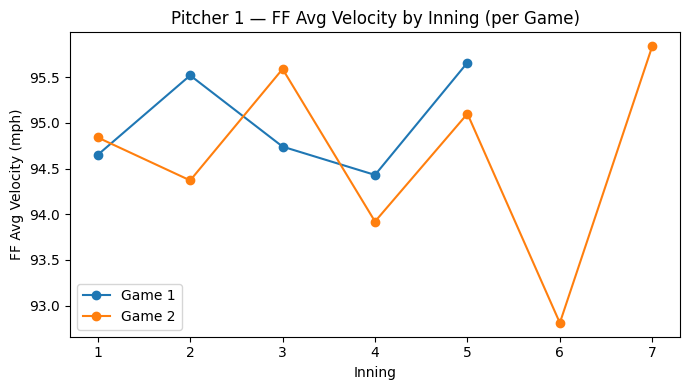

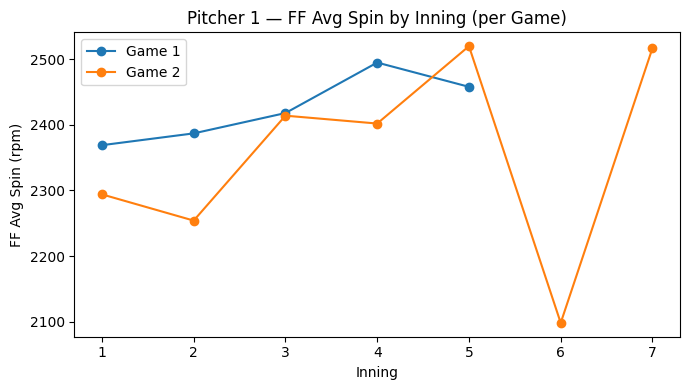

In [ ]:
# ===== FF velo & spin by inning per game =====
if not {"PitchType","ReleaseSpeed","ReleaseSpinRate"}.issubset(p1.columns):
    raise ValueError("缺 PitchType / ReleaseSpeed / ReleaseSpinRate 欄位。")

ff = p1[p1["PitchType"] == "FF"].copy()
ff_tbl = (
    ff.groupby(["GamePk","Inning"], dropna=False)
      .agg(FF_AvgVelo=("ReleaseSpeed","mean"),
           FF_AvgSpin=("ReleaseSpinRate","mean"),
           FF_Pitches=("PitchType","size"))
      .round({"FF_AvgVelo":2,"FF_AvgSpin":0})
      .reset_index()
      .sort_values(["GamePk","Inning"])
)
display(ff_tbl)

# Plot — FF Avg Velocity
plt.figure(figsize=(7,4))
for gpk, sub in ff_tbl.groupby("GamePk"):
    plt.plot(sub["Inning"], sub["FF_AvgVelo"], marker="o", label=f"Game {gpk}")
plt.title(f"Pitcher {PID} — FF Avg Velocity by Inning (per Game)")
plt.xlabel("Inning"); plt.ylabel("FF Avg Velocity (mph)"); plt.legend(); plt.tight_layout(); plt.show()

# Plot — FF Avg Spin
plt.figure(figsize=(7,4))
for gpk, sub in ff_tbl.groupby("GamePk"):
    plt.plot(sub["Inning"], sub["FF_AvgSpin"], marker="o", label=f"Game {gpk}")
plt.title(f"Pitcher {PID} — FF Avg Spin by Inning (per Game)")
plt.xlabel("Inning"); plt.ylabel("FF Avg Spin (rpm)"); plt.legend(); plt.tight_layout(); plt.show()


### Batter

In [33]:
# === Batters Summary — calculations ===
import numpy as np
import pandas as pd

# --- Keys & ordering (never mix games into one PA) ---
KEYS_AB = ["GamePk", "AtBatNumber"]
if "PitchNumber" in clean_df.columns:
    d = clean_df.sort_values(KEYS_AB + ["PitchNumber"]).copy()
else:
    d = clean_df.sort_values(KEYS_AB).copy()

pc = d["PitchCall"].astype(str).str.strip().str.lower()

# --- Pitch / non-pitch flags (in this dataset only pickoffs are non-pitch) ---
is_pickoff = pc.str.startswith("pickoff_")
d["_is_pitch"] = ~is_pickoff

# previous count (for two-strike reach / early-PA)
d["_balls_prev"]   = d.groupby(KEYS_AB)["Balls"].shift(1).fillna(0).astype(int)
d["_strikes_prev"] = d.groupby(KEYS_AB)["Strikes"].shift(1).fillna(0).astype(int)

# --- Last pitch per PA (finisher) — one row per PA ---
last_idx = d[d["_is_pitch"]].groupby(KEYS_AB, as_index=False).tail(1).index
d["_is_last_pitch"] = False
d.loc[last_idx, "_is_last_pitch"] = True

ab = d.loc[d["_is_last_pitch"]].copy()
ab = ab.drop_duplicates(KEYS_AB, keep="last")  # enforce uniqueness per PA
assert not ab.duplicated(KEYS_AB).any(), "PA table has duplicate finishers—check input flags."

# --- Per-PA outcomes from the finisher row ---
PC_HIT = {"single","double","triple","home_run"}
PC_AB  = PC_HIT | {"field_out","force_out","grounded_into_double_play","field_error"}  # sac bunt not AB
TB_MAP = {"single":1, "double":2, "triple":3, "home_run":4}

ab["is_hit"] = ab["PitchCall"].isin(PC_HIT).astype(int)
ab["AB"]     = ab["PitchCall"].isin(PC_AB).astype(int)
ab["BB"]     = ab["PitchCall"].eq("walk").astype(int)
ab["SO"]     = ab["PitchCall"].eq("strikeout").astype(int)
ab["TB"]     = ab["PitchCall"].map(TB_MAP).fillna(0).astype(int)

# --- Two-strike reached: build PA set at pitch-level, then merge back (no many-to-many) ---
ts_pa = (
    d.loc[d["_is_pitch"] & (d["_strikes_prev"] >= 2), KEYS_AB]
    .drop_duplicates()
    .assign(TS_reached=1)
)
ab = ab.merge(ts_pa, on=KEYS_AB, how="left")
ab["TS_reached"] = ab["TS_reached"].fillna(0).astype(int)
# consistency check
assert ts_pa.shape[0] == ab["TS_reached"].sum(), "Two-strike PA counts disagree (pitch vs PA table)."

# --- Early-PA: PA ended within first 3 pitches (count only pitch rows) ---
pitches_in_pa = d[d["_is_pitch"]].groupby(KEYS_AB).size().rename("PitchesInPA")
ab = ab.merge(pitches_in_pa, left_on=KEYS_AB, right_index=True, how="left")
ab["EarlyPA"] = ab["PitchesInPA"].le(3).astype(int)

# --- Batter-level aggregates (from PA table only) ---
gb = ab.groupby("BatterId", dropna=False)

bat = pd.DataFrame({
    "PA":               gb.size(),
    "Pitches/PA":       gb["PitchesInPA"].mean().round(2),
    "H":                gb["is_hit"].sum(),
    "BB":               gb["BB"].sum(),
    "SO":               gb["SO"].sum(),
    "AB":               gb["AB"].sum(),
    "TB":               gb["TB"].sum(),
    "Two-Strike PAs":   gb["TS_reached"].sum(),
    "Early-PA PAs":     gb["EarlyPA"].sum(),
})

# Rate stats (simplified OBP; add HBP/SF if available later)
bat["OBP"] = ((bat["H"] + bat["BB"]) / bat["PA"]).round(3)
bat["SLG"] = (bat["TB"] / bat["AB"].replace(0, np.nan)).fillna(0).round(3)

bat["K%"]  = (bat["SO"] / bat["PA"] * 100).round(1)
bat["BB%"] = (bat["BB"] / bat["PA"] * 100).round(1)
bat["H%"]  = (bat["H"]  / bat["PA"] * 100).round(1)

# Two-strike only metrics (each PA counted once)
ts_ab = ab.loc[ab["TS_reached"].eq(1)].copy()
gb_ts = ts_ab.groupby("BatterId", dropna=False)
ts_hit = gb_ts["is_hit"].sum().rename("TS_H")
ts_bb  = gb_ts["BB"].sum().rename("TS_BB")
ts_paN = gb_ts.size().rename("TS_PA")

bat = bat.join(pd.concat([ts_hit, ts_bb, ts_paN], axis=1), how="left").fillna({"TS_H":0,"TS_BB":0,"TS_PA":0})
bat["Two-Strike Reached %"] = (bat["Two-Strike PAs"] / bat["PA"] * 100).round(1)
bat["Two-Strike Hit%"]      = (bat["TS_H"] / bat["TS_PA"].replace(0, np.nan) * 100).fillna(0).round(1)
bat["Two-Strike OBP"]       = ((bat["TS_H"] + bat["TS_BB"]) / bat["TS_PA"].replace(0, np.nan)).fillna(0).round(3)

# Early-PA only metrics (each PA counted once)
early_ab = ab.loc[ab["EarlyPA"].eq(1)].copy()
gb_early = early_ab.groupby("BatterId", dropna=False)
early_h  = gb_early["is_hit"].sum().rename("EARLY_H")
early_bb = gb_early["BB"].sum().rename("EARLY_BB")
early_pa = gb_early.size().rename("EARLY_PA")

bat = bat.join(pd.concat([early_h, early_bb, early_pa], axis=1), how="left").fillna({"EARLY_H":0,"EARLY_BB":0,"EARLY_PA":0})
bat["Early-PA %"]   = (bat["Early-PA PAs"] / bat["PA"] * 100).round(1)
bat["Early-PA OBP"] = ((bat["EARLY_H"] + bat["EARLY_BB"]) / bat["EARLY_PA"].replace(0, np.nan)).fillna(0).round(3)

# Final select & order
cols = [
    "PA","Pitches/PA","OBP","SLG","K%","BB%","H%",
    "Two-Strike Reached %","Two-Strike Hit%","Two-Strike OBP",
    "Early-PA %","Early-PA OBP"
]
batters_summary = bat.reset_index()[["BatterId"] + cols].sort_values(["PA","BatterId"], ascending=[False, True])

# Short methods note (for your report/appendix)
methods_note = (
    "Methods note: Every row is a pitch event except pickoffs (excluded). "
    "PA is keyed by (GamePk, AtBatNumber) and ordered by PitchNumber. "
    "Two-strike definitions: process = pitches with prev strikes ≥2; outcome = one finisher per PA. "
    "All two-strike and early-PA metrics are computed at the PA level (deduped), so each PA counts once. "
    "OBP uses a simplified formula (H+BB)/PA due to limited fields; add HBP/SF if available. "
    "Rates are descriptive, not diagnostic (two games)."
)
print(methods_note)

batters_summary.head(3)

Methods note: Every row is a pitch event except pickoffs (excluded). PA is keyed by (GamePk, AtBatNumber) and ordered by PitchNumber. Two-strike definitions: process = pitches with prev strikes ≥2; outcome = one finisher per PA. All two-strike and early-PA metrics are computed at the PA level (deduped), so each PA counts once. OBP uses a simplified formula (H+BB)/PA due to limited fields; add HBP/SF if available. Rates are descriptive, not diagnostic (two games).


,BatterId,PA,Pitches/PA,OBP,SLG,K%,BB%,H%,Two-Strike Reached %,Two-Strike Hit%,Two-Strike OBP,Early-PA %,Early-PA OBP
18,19,10,3.3,0.2,0.333,40.0,0.0,20.0,20.0,0.0,0.0,60.0,0.333
20,21,10,3.6,0.6,0.625,10.0,10.0,50.0,10.0,0.0,0.0,50.0,0.800
23,24,10,3.1,0.4,0.400,0.0,0.0,40.0,20.0,50.0,0.5,70.0,0.429


In [34]:
# === Save CSV ===
out_path = "batters_summary.csv"
batters_summary.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: batters_summary.csv


In [35]:
# 1) PA>=5
b5 = batters_summary.query("PA >= 5").copy()

# 2) Highlights
top_obp = b5.sort_values("OBP", ascending=False).head(5)
top_slg = b5.sort_values("SLG", ascending=False).head(5)
grinders = b5.sort_values("Pitches/PA", ascending=False).head(5)
aggressive = b5.sort_values("Early-PA %", ascending=False).head(5)
ts_survive = b5.sort_values("Two-Strike OBP", ascending=False).head(5)

# 3) Labels
def tag_row(r):
    tags = []
    if r["OBP"] >= 0.400: tags.append("on-base hot")
    if r["SLG"] >= 0.500: tags.append("impact")
    if r["Pitches/PA"] >= 4.2: tags.append("grindy")
    if r["Early-PA %"] >= 50: tags.append("aggressive early")
    if r["Two-Strike OBP"] >= 0.300: tags.append("2S survive")
    return ", ".join(tags)

b5["Tags"] = b5.apply(tag_row, axis=1)
b5 = b5.sort_values(["OBP","SLG"], ascending=[False, False])
b5

,BatterId,PA,Pitches/PA,OBP,SLG,K%,BB%,H%,Two-Strike Reached %,Two-Strike Hit%,Two-Strike OBP,Early-PA %,Early-PA OBP,Tags
20,21,10,3.60,0.600,0.625,10.0,10.0,50.0,10.0,0.0,0.0,50.0,0.800,"on-base hot, impact, aggressive early"
33,34,9,3.22,0.556,0.833,11.1,22.2,33.3,11.1,0.0,0.0,55.6,0.400,"on-base hot, impact, aggressive early"
13,14,5,3.40,0.400,1.000,20.0,0.0,40.0,40.0,50.0,0.5,60.0,0.333,"on-base hot, impact, aggressive early, 2S survive"
6,7,5,4.00,0.400,0.500,20.0,0.0,40.0,40.0,50.0,0.5,40.0,0.500,"on-base hot, impact, 2S survive"
23,24,10,3.10,0.400,0.400,0.0,0.0,40.0,20.0,50.0,0.5,70.0,0.429,"on-base hot, aggressive early, 2S survive"
16,17,5,5.00,0.400,0.333,20.0,20.0,20.0,60.0,0.0,0.0,20.0,1.000,"on-base hot, grindy"
17,18,7,4.14,0.286,0.250,28.6,14.3,14.3,14.3,0.0,0.0,42.9,0.000,
12,13,9,4.22,0.222,0.800,33.3,11.1,11.1,11.1,0.0,0.0,11.1,1.000,"impact, grindy"
3,4,9,3.67,0.222,0.333,0.0,0.0,22.2,22.2,0.0,0.0,55.6,0.200,aggressive early
19,20,5,3.60,0.200,0.800,0.0,0.0,20.0,40.0,50.0,0.5,60.0,0.000,"impact, aggressive early, 2S survive"


In [36]:
# === Save CSV ===
out_path = "batters_PA5_summary.csv"
b5.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: batters_PA5_summary.csv
